# BUDT758T - FINAL PROJECT

## Import the necessary packages

In [ ]:
# Yelp Top-Useful Prediction
# Super Advanced 85+ Version
#
# Includes:
# 1. External data source: US holiday calendar
# 2. 10+ feature insight tables/charts
# 3. 6+ model comparison
# 4. Cross-validation
# 5. Learning curve
# 6. Tuning curve
# 7. Model zoo: many LGB/XGB/MLP variants
# 8. Advanced top-K random blend
# 9. Final submission under FPR <= 0.097

import os
import gc
import ast
import json
import re
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import lightgbm as lgb
import xgboost as xgb
import holidays

## Import dataset and configure initial settings

In [ ]:
# 1. Settings

RANDOM_STATE = 42
N_JOBS = -1

# import dataset
DATA_DIR = r"C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample"
OUTPUT_DIR = DATA_DIR

FPR_LIMIT = 0.10
FPR_LIMIT_FINAL = 0.097

# The result from last submission
CURRENT_BEST_TPR = 0.7356718721389521
CURRENT_BEST_FPR = 0.09698189570279951

# change user.useful to False because it is leakage
USE_USER_USEFUL_FEATURES = True

# To run the blocks required for the report:: 6 models / CV / learning curve / tuning curve
RUN_REPORT_BLOCKS = True

# Whether to run more models
RUN_EXTRA_LGB = True
RUN_EXTRA_XGB = True
RUN_EXTRA_MLP = True

# For strong computer
MODEL_COMPARE_SAMPLE_SIZE = 200000
CURVE_SAMPLE_SIZE = 400000

# Advanced blend settings
TOP_K_FOR_BLEND = 12
BLEND_SEARCH_SAMPLE_SIZE = 200000
RANDOM_BLEND_TRIALS = 30000
RANDOM_BLEND_TOP_EVAL = 300

# MLP seeds
MLP_SEEDS = [99, 42, 21, 1, 123]

# Whether to use GPU for XGBoost
# Default is False to prevent environment-related errors
# If XGBoost supports CUDA, you can change it to True
USE_XGB_GPU = False

print("Settings loaded.")

Settings loaded.


## Load datasets and inspect data structure

In [ ]:
# 2. Load Data

def read_csv_from_data_dir(filename):
    path = os.path.join(DATA_DIR, filename)
    print("Reading:", path)
    return pd.read_csv(path)

# Read csv files
train_x = read_csv_from_data_dir("review_train_x.csv")
train_y = read_csv_from_data_dir("review_train_y.csv")
test_x = read_csv_from_data_dir("review_test_x.csv")
business = read_csv_from_data_dir("business.csv")
user = read_csv_from_data_dir("user.csv")
tip = read_csv_from_data_dir("tip.csv")

if train_y.shape[1] == 1:
    y = train_y.iloc[:, 0].astype(int).reset_index(drop=True)
else:
    y = train_y["top_useful"].astype(int).reset_index(drop=True)

# Find distribution and shapes
print("train_x:", train_x.shape)
print("train_y:", train_y.shape)
print("test_x:", test_x.shape)
print("business:", business.shape)
print("user:", user.shape)
print("tip:", tip.shape)

print("\nLabel distribution:")
print(y.value_counts())
print("Positive rate:", y.mean())

Reading: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\review_train_x.csv
Reading: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\review_train_y.csv
Reading: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\review_test_x.csv
Reading: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\business.csv
Reading: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\user.csv
Reading: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\tip.csv
train_x: (1577278, 6)
train_y: (1577278, 1)
test_x: (700000, 6)
business: (15000, 13)
user: (992656, 8)
tip: (300865, 5)

Label distribution:
top_useful
0    1386131
1     191147
Name: count, dtype: int64
Positive rate: 0.1211878945880181


## Define evaluation functions for model performance assessment

In [ ]:
# ============================================================
# 3. Evaluation Functions
# ============================================================

# Find the best TPR under a specific FPR limit
def best_tpr_under_fpr(y_true, y_score, fpr_limit=0.10):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    valid_idx = np.where(fpr <= fpr_limit)[0]

    if len(valid_idx) == 0:
        return {
            "auc": roc_auc_score(y_true, y_score),
            "fpr": np.nan,
            "tpr": np.nan,
            "threshold": np.nan,
            "accuracy": np.nan,
            "tn": np.nan,
            "fp": np.nan,
            "fn": np.nan,
            "tp": np.nan
        }

    best_idx = valid_idx[np.argmax(tpr[valid_idx])]
    best_threshold = thresholds[best_idx]

    y_pred = (y_score >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "auc": roc_auc_score(y_true, y_score),
        "fpr": fp / (fp + tn),
        "tpr": tp / (tp + fn),
        "threshold": best_threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def print_metrics(name, metrics):
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    for k, v in metrics.items():
        print(f"{k}: {v}")


def get_model_score(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    else:
        return model.decision_function(X_data)

## Create external holiday-based features from review dates
This section adds U.S. holiday-related variables based on each review date. It identifies whether a review was written on a U.S. holiday, calculates how many days the review is from the nearest holiday, and measures the days since the previous holiday and until the next holiday. It also creates holiday-window indicators, such as whether the review was written within 3 or 7 days of a holiday. 

In [5]:
# ============================================================
# 4. External Holiday Features
# ============================================================

def add_us_holiday_features(df):
    df = df.copy()

    if "date" not in df.columns:
        df["is_us_holiday"] = 0.0
        df["days_to_nearest_holiday"] = 999.0
        df["days_since_previous_holiday"] = 999.0
        df["days_until_next_holiday"] = 999.0
        df["is_holiday_window_3"] = 0.0
        df["is_holiday_window_7"] = 0.0
        df["is_before_holiday_3"] = 0.0
        df["is_after_holiday_3"] = 0.0
        return df

    date_series = pd.to_datetime(df["date"], errors="coerce")
    years = date_series.dt.year.dropna().astype(int)

    if len(years) == 0:
        min_year, max_year = 2004, 2023
    else:
        min_year = int(years.min()) - 1
        max_year = int(years.max()) + 1

    us_holidays = holidays.US(years=range(min_year, max_year + 1))
    holiday_dates = sorted(list(us_holidays.keys()))

    holiday_ord = np.array(
        pd.to_datetime(holiday_dates).values.astype("datetime64[D]").astype("int64")
    )

    date_day = date_series.dt.floor("D")
    valid_mask = date_series.notna().values
    date_ord_all = date_day.values.astype("datetime64[D]").astype("int64")

    is_holiday = np.zeros(len(df), dtype="float32")
    nearest_days = np.full(len(df), 999.0, dtype="float32")
    since_prev = np.full(len(df), 999.0, dtype="float32")
    until_next = np.full(len(df), 999.0, dtype="float32")

    valid_dates = date_ord_all[valid_mask]

    idx = np.searchsorted(holiday_ord, valid_dates)

    has_prev = idx > 0
    has_next = idx < len(holiday_ord)

    prev_days = np.full(len(valid_dates), 999.0)
    next_days = np.full(len(valid_dates), 999.0)

    prev_days[has_prev] = valid_dates[has_prev] - holiday_ord[idx[has_prev] - 1]
    next_days[has_next] = holiday_ord[idx[has_next]] - valid_dates[has_next]

    exact_holiday = np.isin(valid_dates, holiday_ord)
    prev_days[exact_holiday] = 0
    next_days[exact_holiday] = 0

    nearest = np.minimum(prev_days, next_days)

    is_holiday[valid_mask] = exact_holiday.astype("float32")
    nearest_days[valid_mask] = nearest.astype("float32")
    since_prev[valid_mask] = prev_days.astype("float32")
    until_next[valid_mask] = next_days.astype("float32")

    df["is_us_holiday"] = is_holiday
    df["days_to_nearest_holiday"] = nearest_days
    df["days_since_previous_holiday"] = since_prev
    df["days_until_next_holiday"] = until_next

    df["is_holiday_window_3"] = (df["days_to_nearest_holiday"] <= 3).astype("float32")
    df["is_holiday_window_7"] = (df["days_to_nearest_holiday"] <= 7).astype("float32")
    df["is_before_holiday_3"] = (df["days_until_next_holiday"] <= 3).astype("float32")
    df["is_after_holiday_3"] = (df["days_since_previous_holiday"] <= 3).astype("float32")

    return df

## Create review-level text, sentiment, date, rating, and holiday features
This section transforms raw review data into rich review-level predictors by engineering features from multiple dimensions of each review. It extracts textual structure features such as review length, word count, sentence count, punctuation usage, capitalization patterns, and digit frequency; builds simple sentiment indicators using predefined positive and negative keyword counts; captures temporal patterns from review dates including year, month, weekday, weekend behavior, and holiday proximity; and incorporates star rating behavior through positive, negative, and extreme rating flags. Together, these features convert unstructured review text and metadata into machine-learning-ready variables that capture writing style, sentiment tone, timing effects, and rating behavior.

In [6]:
# ============================================================
# 5. Review-Level Features
# ============================================================

def add_review_features(df):
    df = df.copy()

    if "text" not in df.columns:
        df["text"] = ""

    df["text"] = df["text"].fillna("").astype(str)

    df["text_len"] = df["text"].str.len().astype("float32")
    df["word_count"] = df["text"].str.split().str.len().astype("float32")
    df["avg_word_len"] = df["text_len"] / (df["word_count"] + 1)

    df["sentence_count"] = df["text"].str.count(r"[.!?]+").astype("float32")
    df["exclaim_count"] = df["text"].str.count("!").astype("float32")
    df["question_count"] = df["text"].str.count(r"\?").astype("float32")
    df["comma_count"] = df["text"].str.count(",").astype("float32")
    df["period_count"] = df["text"].str.count(r"\.").astype("float32")
    df["digit_count"] = df["text"].str.count(r"\d").astype("float32")

    df["upper_count"] = df["text"].str.count(r"[A-Z]").astype("float32")
    df["upper_ratio"] = df["upper_count"] / (df["text_len"] + 1)
    df["upper_per_word"] = df["upper_count"] / (df["word_count"] + 1)

    df["log_text_len"] = np.log1p(df["text_len"].clip(lower=0))
    df["log_word_count"] = np.log1p(df["word_count"].clip(lower=0))

    df["punctuation_total"] = (
            df["exclaim_count"] +
            df["question_count"] +
            df["comma_count"] +
            df["period_count"]
    )

    df["period_per_word"] = df["period_count"] / (df["word_count"] + 1)
    df["punctuation_per_word"] = df["punctuation_total"] / (df["word_count"] + 1)

    positive_words = [
        "good", "great", "excellent", "amazing", "awesome", "best",
        "love", "loved", "perfect", "delicious", "friendly", "nice",
        "wonderful", "fantastic", "recommend", "favorite", "fresh",
        "clean", "fast", "helpful", "enjoyed"
    ]

    negative_words = [
        "bad", "terrible", "awful", "worst", "hate", "hated",
        "poor", "rude", "slow", "dirty", "disappointed",
        "horrible", "never", "overpriced", "cold", "bland",
        "wait", "waiting", "wrong", "expensive"
    ]

    text_lower = df["text"].str.lower()

    df["positive_word_count"] = 0
    for w in positive_words:
        df["positive_word_count"] += text_lower.str.count(r"\b" + w + r"\b")

    df["negative_word_count"] = 0
    for w in negative_words:
        df["negative_word_count"] += text_lower.str.count(r"\b" + w + r"\b")

    df["positive_word_count"] = df["positive_word_count"].astype("float32")
    df["negative_word_count"] = df["negative_word_count"].astype("float32")

    df["sentiment_balance"] = df["positive_word_count"] - df["negative_word_count"]
    df["positive_word_ratio"] = df["positive_word_count"] / (df["word_count"] + 1)
    df["negative_word_ratio"] = df["negative_word_count"] / (df["word_count"] + 1)

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["review_year"] = df["date"].dt.year.astype("float32")
        df["review_month"] = df["date"].dt.month.astype("float32")
        df["review_dayofweek"] = df["date"].dt.dayofweek.astype("float32")
        df["review_hour"] = df["date"].dt.hour.astype("float32")
        df["is_weekend"] = df["review_dayofweek"].isin([5, 6]).astype("float32")
    else:
        df["review_year"] = np.nan
        df["review_month"] = np.nan
        df["review_dayofweek"] = np.nan
        df["review_hour"] = np.nan
        df["is_weekend"] = np.nan

    if "stars" in df.columns:
        df["review_stars"] = pd.to_numeric(df["stars"], errors="coerce").astype("float32")
    else:
        df["review_stars"] = np.nan

    df["is_extreme_star"] = ((df["review_stars"] <= 2) | (df["review_stars"] >= 5)).astype("float32")
    df["is_positive_star"] = (df["review_stars"] >= 4).astype("float32")
    df["is_negative_star"] = (df["review_stars"] <= 2).astype("float32")

    df = add_us_holiday_features(df)

    return df

## Clean and create business-level features from business metadata
This section processes the raw business dataset and transforms business information into structured numerical features for modeling. It cleans core variables such as ratings, review counts, location, and open status, parses business categories into keyword-based indicators, extracts and converts nested business attributes (such as price range, WiFi, alcohol, reservations, and delivery options), and derives operational features like days open and average daily hours from business hours data. The goal is to convert complex categorical and semi-structured business metadata into machine-learning-ready business-level predictors.

In [ ]:
# ============================================================
# 6. Business Features
# ============================================================

def parse_attr_dict(val):
    if isinstance(val, dict):
        return val

    if pd.isna(val):
        return {}

    s = str(val)

    try:
        return json.loads(
            s.replace("'", '"')
            .replace("True", "true")
            .replace("False", "false")
            .replace("None", "null")
        )
    except Exception:
        try:
            return ast.literal_eval(s)
        except Exception:
            return {}


def get_numeric_col(df, col, default=np.nan):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    else:
        return pd.Series([default] * len(df), index=df.index)


def attr_to_number(attr_dict, key):
    val = attr_dict.get(key, np.nan)

    if isinstance(val, bool):
        return float(val)

    if pd.isna(val):
        return np.nan

    val_str = str(val).strip().strip("'\"").lower()

    if val_str in ["true", "1", "yes"]:
        return 1.0
    if val_str in ["false", "0", "no"]:
        return 0.0
    if val_str in ["none", "nan", "null", ""]:
        return np.nan

    try:
        return float(val_str)
    except Exception:
        return np.nan


def map_attr_value(val, mapping):
    if pd.isna(val):
        return np.nan

    val_str = str(val).strip().strip("'\"").lower()
    return mapping.get(val_str, np.nan)


def clean_business_features(business):
    b = business.copy()
    b = b.drop_duplicates(subset=["business_id"], keep="first")

    b["business_stars"] = get_numeric_col(b, "stars").astype("float32")
    b["business_review_count"] = get_numeric_col(b, "review_count").astype("float32")
    b["is_open"] = get_numeric_col(b, "is_open", default=0).fillna(0).astype("float32")
    b["latitude"] = get_numeric_col(b, "latitude").astype("float32")
    b["longitude"] = get_numeric_col(b, "longitude").astype("float32")

    b["log_business_review_count"] = np.log1p(b["business_review_count"].clip(lower=0))

    if "categories" in b.columns:
        b["categories"] = b["categories"].fillna("").astype(str).str.lower()
    else:
        b["categories"] = ""

    b["category_count"] = b["categories"].apply(
        lambda x: 0 if x == "" else len([c for c in x.split(",") if c.strip()])
    ).astype("float32")

    category_keywords = {
        "cat_restaurant": "restaurant",
        "cat_food": "food",
        "cat_bar": "bar",
        "cat_nightlife": "nightlife",
        "cat_coffee": "coffee",
        "cat_shopping": "shopping",
        "cat_beauty": "beauty",
        "cat_hotel": "hotel",
        "cat_auto": "auto",
        "cat_health": "health",
        "cat_mexican": "mexican",
        "cat_chinese": "chinese",
        "cat_japanese": "japanese",
        "cat_american": "american",
        "cat_pizza": "pizza",
        "cat_burgers": "burgers",
        "cat_seafood": "seafood",
        "cat_breakfast": "breakfast",
        "cat_fastfood": "fast food",
        "cat_italian": "italian",
        "cat_sushi": "sushi",
        "cat_sandwich": "sandwich",
        "cat_event": "event planning",
        "cat_service": "services"
    }

    for new_col, keyword in category_keywords.items():
        b[new_col] = b["categories"].str.contains(keyword, regex=False).astype("float32")

    if "attributes" in b.columns:
        attrs = b["attributes"].apply(parse_attr_dict)
    else:
        attrs = pd.Series([{} for _ in range(len(b))], index=b.index)

    simple_attr_keys = [
        "BusinessAcceptsCreditCards",
        "BikeParking",
        "ByAppointmentOnly",
        "RestaurantsReservations",
        "RestaurantsGoodForGroups",
        "RestaurantsTakeOut",
        "GoodForKids",
        "HasTV",
        "Caters",
        "HappyHour",
        "OutdoorSeating",
        "RestaurantsDelivery",
        "RestaurantsTableService",
        "WheelchairAccessible",
        "DogsAllowed"
    ]

    for key in simple_attr_keys:
        b["attr_" + key] = attrs.apply(lambda d: attr_to_number(d, key)).astype("float32")

    attire_map = {"casual": 1.0, "dressy": 2.0, "formal": 3.0}
    alcohol_map = {"none": 0.0, "beer_and_wine": 1.0, "full_bar": 2.0}
    noise_map = {"quiet": 1.0, "average": 2.0, "loud": 3.0, "very_loud": 4.0}
    wifi_map = {"no": 0.0, "free": 1.0, "paid": 2.0}

    price_raw = attrs.apply(lambda d: d.get("RestaurantsPriceRange2", np.nan))
    b["attr_RestaurantsPriceRange2"] = pd.to_numeric(price_raw, errors="coerce").astype("float32")

    b["attr_RestaurantsAttire"] = attrs.apply(
        lambda d: map_attr_value(d.get("RestaurantsAttire", np.nan), attire_map)
    ).astype("float32")

    b["attr_Alcohol"] = attrs.apply(
        lambda d: map_attr_value(d.get("Alcohol", np.nan), alcohol_map)
    ).astype("float32")

    b["attr_NoiseLevel"] = attrs.apply(
        lambda d: map_attr_value(d.get("NoiseLevel", np.nan), noise_map)
    ).astype("float32")

    b["attr_WiFi"] = attrs.apply(
        lambda d: map_attr_value(d.get("WiFi", np.nan), wifi_map)
    ).astype("float32")

    def parse_hours(val):
        if pd.isna(val):
            return 0, 0.0

        try:
            h = ast.literal_eval(str(val))
            if not isinstance(h, dict):
                return 0, 0.0

            days_open = len(h)
            total_hours = 0.0

            for _, timerange in h.items():
                parts = str(timerange).split("-")
                if len(parts) != 2:
                    continue

                s1 = parts[0].split(":")
                s2 = parts[1].split(":")

                start = float(s1[0]) + float(s1[1]) / 60
                end = float(s2[0]) + float(s2[1]) / 60

                diff = end - start
                if diff < 0:
                    diff += 24

                total_hours += diff

            avg_hours = total_hours / days_open if days_open > 0 else 0.0
            return days_open, avg_hours

        except Exception:
            return 0, 0.0

    if "hours" in b.columns:
        hours_parsed = b["hours"].apply(parse_hours)
        b["days_open"] = hours_parsed.apply(lambda x: x[0]).astype("float32")
        b["avg_hours_per_day"] = hours_parsed.apply(lambda x: x[1]).astype("float32")
    else:
        b["days_open"] = 0.0
        b["avg_hours_per_day"] = 0.0

    keep_cols = [
        "business_id",
        "business_stars",
        "business_review_count",
        "log_business_review_count",
        "is_open",
        "latitude",
        "longitude",
        "category_count",
        "days_open",
        "avg_hours_per_day"
    ]

    keep_cols += list(category_keywords.keys())
    keep_cols += ["attr_" + key for key in simple_attr_keys]
    keep_cols += [
        "attr_RestaurantsPriceRange2",
        "attr_RestaurantsAttire",
        "attr_Alcohol",
        "attr_NoiseLevel",
        "attr_WiFi"
    ]

    keep_cols = [c for c in keep_cols if c in b.columns]

    return b[keep_cols]

## Clean and create user-level features from user metadata
This section transforms raw user information into structured user-level predictors for modeling. It removes duplicate users, converts numerical user statistics such as review count, funny votes, cool votes, fans, and average stars into usable numeric features, and optionally includes user useful votes depending on the leakage setting. It also creates behavioral features such as elite-year count, friend count, and the year the user started using Yelp. 

In [8]:
# ============================================================
# 7. User Features
# ============================================================

def clean_user_features(user):
    u = user.copy()
    u = u.drop_duplicates(subset=["user_id"], keep="first")

    numeric_cols = ["review_count", "funny", "cool", "fans", "average_stars"]

    if USE_USER_USEFUL_FEATURES:
        numeric_cols.append("useful")

    for col in numeric_cols:
        if col in u.columns:
            u["user_" + col] = pd.to_numeric(u[col], errors="coerce").astype("float32")
        else:
            u["user_" + col] = np.nan

    if "elite" in u.columns:
        u["elite"] = u["elite"].fillna("").astype(str)
        u["elite"] = u["elite"].str.replace("20,20", "2020", regex=False)

        u["user_elite_count"] = u["elite"].apply(
            lambda x: 0 if x.strip() == "" or x.lower() in ["nan", "none"]
            else len([i for i in x.split(",") if i.strip()])
        ).astype("float32")
    else:
        u["user_elite_count"] = 0.0

    if "friends" in u.columns:
        u["friends"] = u["friends"].fillna("").astype(str)
        u["user_friend_count"] = u["friends"].apply(
            lambda x: 0 if x.strip() == "" or x.lower() in ["none", "nan"]
            else len([i for i in x.split(",") if i.strip()])
        ).astype("float32")
    else:
        u["user_friend_count"] = 0.0

    if "yelping_since" in u.columns:
        u["yelping_since"] = pd.to_datetime(u["yelping_since"], errors="coerce")
        u["yelping_since_year"] = u["yelping_since"].dt.year.astype("float32")
    else:
        u["yelping_since_year"] = np.nan

    keep_cols = ["user_id"]
    keep_cols += ["user_" + col for col in numeric_cols]
    keep_cols += [
        "user_elite_count",
        "user_friend_count",
        "yelping_since_year"
    ]

    keep_cols = [c for c in keep_cols if c in u.columns]

    return u[keep_cols]

## Aggregate tip-level features for businesses and users
This section summarizes tip data into business-level and user-level aggregated features. It extracts basic text characteristics from tips, such as text length and word count, incorporates compliment counts, and then groups the data separately by business and by user. For each business and user, it calculates total tip volume, average tip length, average tip word count, and total compliments received.

In [9]:
# ============================================================
# 8. Tip Aggregation
# ============================================================

def aggregate_tip_features(tip):
    t = tip.copy()

    if "text" not in t.columns:
        t["text"] = ""

    t["text"] = t["text"].fillna("").astype(str)
    t["tip_text_len"] = t["text"].str.len().astype("float32")
    t["tip_word_count"] = t["text"].str.split().str.len().astype("float32")

    if "compliment_count" in t.columns:
        t["compliment_count"] = pd.to_numeric(
            t["compliment_count"], errors="coerce"
        ).fillna(0).astype("float32")
    else:
        t["compliment_count"] = 0.0

    tip_business = t.groupby("business_id", as_index=False).agg(
        business_tip_count=("text", "count"),
        business_tip_avg_len=("tip_text_len", "mean"),
        business_tip_avg_words=("tip_word_count", "mean"),
        business_tip_compliments=("compliment_count", "sum")
    )

    tip_user = t.groupby("user_id", as_index=False).agg(
        user_tip_count=("text", "count"),
        user_tip_avg_len=("tip_text_len", "mean"),
        user_tip_avg_words=("tip_word_count", "mean"),
        user_tip_compliments=("compliment_count", "sum")
    )

    for df in [tip_business, tip_user]:
        for c in df.columns:
            if c not in ["business_id", "user_id"]:
                df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")

    return tip_business, tip_user

## Build final feature tables for training and testing
This section combines all engineered features into the final training and testing feature tables. It first creates cleaned business features, user features, and aggregated tip features, then applies review-level feature engineering to both train and test datasets. After that, it merges business-level, user-level, business-tip, and user-tip features into the review data using business_id and user_id. Finally, it prints the table dimensions and total processing time to confirm the feature-building process.

In [10]:
# ============================================================
# 9. Build Feature Tables
# ============================================================

t0 = time.time()

business_clean = clean_business_features(business)
user_clean = clean_user_features(user)
tip_business, tip_user = aggregate_tip_features(tip)

print("business_clean:", business_clean.shape)
print("user_clean:", user_clean.shape)
print("tip_business:", tip_business.shape)
print("tip_user:", tip_user.shape)

train_fe = add_review_features(train_x)
test_fe = add_review_features(test_x)

print("train_fe before merge:", train_fe.shape)
print("test_fe before merge:", test_fe.shape)

train_fe = train_fe.merge(business_clean, on="business_id", how="left")
test_fe = test_fe.merge(business_clean, on="business_id", how="left")

train_fe = train_fe.merge(user_clean, on="user_id", how="left")
test_fe = test_fe.merge(user_clean, on="user_id", how="left")

train_fe = train_fe.merge(tip_business, on="business_id", how="left")
test_fe = test_fe.merge(tip_business, on="business_id", how="left")

train_fe = train_fe.merge(tip_user, on="user_id", how="left")
test_fe = test_fe.merge(tip_user, on="user_id", how="left")

print("train_fe after merge:", train_fe.shape)
print("test_fe after merge:", test_fe.shape)
print("Feature table time:", (time.time() - t0) / 60, "minutes")

business_clean: (15000, 54)
user_clean: (992656, 10)
tip_business: (14686, 5)
tip_user: (141177, 5)
train_fe before merge: (1577278, 45)
test_fe before merge: (700000, 45)
train_fe after merge: (1577278, 115)
test_fe after merge: (700000, 115)
Feature table time: 15.6989927927653 minutes


## Create interaction, ratio, and log-transformed features
This section adds advanced engineered features to capture relationships between review, user, and business information. It calculates rating differences between the review rating, business average rating, and user average rating, applies log transformations to reduce skewness in count-based variables, and creates per-review ratios such as user feedback per review and fans per review. It also builds interaction features, such as review length combined with user activity, business popularity, tip counts, and rating sentiment. These features help the model capture more complex patterns that simple individual variables may miss.

In [11]:
# ============================================================
# 10. Interaction, Ratio, Log Features
# ============================================================

for df in [train_fe, test_fe]:

    df["star_diff_from_business"] = df["review_stars"] - df["business_stars"]
    df["user_star_diff"] = df["review_stars"] - df["user_average_stars"]

    df["abs_star_diff_from_business"] = df["star_diff_from_business"].abs()
    df["abs_user_star_diff"] = df["user_star_diff"].abs()

    df["log_user_review_count"] = np.log1p(df["user_review_count"].fillna(0).clip(lower=0))
    df["log_user_fans"] = np.log1p(df["user_fans"].fillna(0).clip(lower=0))
    df["log_user_friend_count"] = np.log1p(df["user_friend_count"].fillna(0).clip(lower=0))
    df["log_user_elite_count"] = np.log1p(df["user_elite_count"].fillna(0).clip(lower=0))

    if USE_USER_USEFUL_FEATURES and "user_useful" in df.columns:
        df["log_user_useful"] = np.log1p(df["user_useful"].fillna(0).clip(lower=0))
    else:
        df["user_useful"] = 0.0
        df["log_user_useful"] = 0.0

    if "user_funny" not in df.columns:
        df["user_funny"] = 0.0

    if "user_cool" not in df.columns:
        df["user_cool"] = 0.0

    df["log_user_funny"] = np.log1p(df["user_funny"].fillna(0).clip(lower=0))
    df["log_user_cool"] = np.log1p(df["user_cool"].fillna(0).clip(lower=0))

    df["user_total_feedback"] = df["user_useful"] + df["user_funny"] + df["user_cool"]
    df["log_user_total_feedback"] = np.log1p(df["user_total_feedback"].fillna(0).clip(lower=0))

    df["user_feedback_per_review"] = df["user_total_feedback"] / (df["user_review_count"] + 1)
    df["user_useful_per_review"] = df["user_useful"] / (df["user_review_count"] + 1)
    df["user_funny_per_review"] = df["user_funny"] / (df["user_review_count"] + 1)
    df["user_cool_per_review"] = df["user_cool"] / (df["user_review_count"] + 1)
    df["user_fans_per_review"] = df["user_fans"] / (df["user_review_count"] + 1)

    df["user_useful_share"] = df["user_useful"] / (df["user_total_feedback"] + 1)
    df["user_funny_share"] = df["user_funny"] / (df["user_total_feedback"] + 1)
    df["user_cool_share"] = df["user_cool"] / (df["user_total_feedback"] + 1)

    df["review_len_x_user_review_count"] = df["log_text_len"] * df["log_user_review_count"]
    df["review_len_x_user_useful"] = df["log_text_len"] * df["user_useful_per_review"]
    df["log_text_x_log_user_useful"] = df["log_text_len"] * df["log_user_useful"]
    df["log_text_x_user_feedback_per_review"] = df["log_text_len"] * df["user_feedback_per_review"]
    df["log_word_x_log_user_useful"] = df["log_word_count"] * df["log_user_useful"]

    df["business_popularity_x_star_diff"] = df["log_business_review_count"] * df["star_diff_from_business"]
    df["business_popularity_x_text_len"] = df["log_business_review_count"] * df["log_text_len"]
    df["log_text_x_log_business_reviews"] = df["log_text_len"] * df["log_business_review_count"]
    df["log_word_x_log_business_reviews"] = df["log_word_count"] * df["log_business_review_count"]

    df["negative_long_review"] = df["is_negative_star"] * df["log_text_len"]
    df["positive_long_review"] = df["is_positive_star"] * df["log_text_len"]
    df["extreme_long_review"] = df["is_extreme_star"] * df["log_text_len"]

    df["log_business_tip_count"] = np.log1p(df["business_tip_count"].fillna(0).clip(lower=0))
    df["log_user_tip_count"] = np.log1p(df["user_tip_count"].fillna(0).clip(lower=0))

    df["business_tip_x_text_len"] = df["log_business_tip_count"] * df["log_text_len"]
    df["user_tip_x_text_len"] = df["log_user_tip_count"] * df["log_text_len"]

train_fe = train_fe.loc[:, ~train_fe.columns.duplicated()]
test_fe = test_fe.loc[:, ~test_fe.columns.duplicated()]

print("train_fe after interaction:", train_fe.shape)
print("test_fe after interaction:", test_fe.shape)

gc.collect()

train_fe after interaction: (1577278, 152)
test_fe after interaction: (700000, 152)


20

## Create out-of-fold target encoding features
This section creates target encoding features for high-cardinality variables such as user_id, business_id, review year, and review stars. It uses out-of-fold encoding to reduce data leakage by calculating encoded values from training folds only, then applies smoothed full-data encoding to the test set. It also creates target-encoding interaction features with review length and user/business combinations. These features help the model capture historical usefulness patterns by user, business, rating, and time while controlling overfitting.

In [ ]:
# 11. Out-of-Fold Target Encoding

def add_oof_target_encoding(
        train_df,
        test_df,
        y,
        cols,
        n_splits=5,
        smoothing=30,
        random_state=42
):
    train_df = train_df.copy()
    test_df = test_df.copy()
    y = pd.Series(y).reset_index(drop=True)

    global_mean = y.mean()

    if isinstance(cols, str):
        cols = [cols]

    enc_name = "te_" + "_".join(cols)

    key_train = train_df[cols].astype(str).agg("_".join, axis=1)
    key_test = test_df[cols].astype(str).agg("_".join, axis=1)

    oof_values = np.zeros(len(train_df), dtype="float32")

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    for tr_idx, va_idx in skf.split(train_df, y):
        fold_key_train = key_train.iloc[tr_idx]
        fold_y_train = y.iloc[tr_idx]

        stats = pd.DataFrame({
            "key": fold_key_train.values,
            "target": fold_y_train.values
        }).groupby("key")["target"].agg(["mean", "count"])

        stats["smooth"] = (
                                  stats["mean"] * stats["count"] + global_mean * smoothing
                          ) / (stats["count"] + smoothing)

        val_keys = key_train.iloc[va_idx]
        oof_values[va_idx] = val_keys.map(stats["smooth"]).fillna(global_mean).astype("float32")

    full_stats = pd.DataFrame({
        "key": key_train.values,
        "target": y.values
    }).groupby("key")["target"].agg(["mean", "count"])

    full_stats["smooth"] = (
                                   full_stats["mean"] * full_stats["count"] + global_mean * smoothing
                           ) / (full_stats["count"] + smoothing)

    train_df[enc_name] = oof_values
    test_df[enc_name] = key_test.map(full_stats["smooth"]).fillna(global_mean).astype("float32")

    print("Added target encoding:", enc_name)

    return train_df, test_df


y_series = pd.Series(y).reset_index(drop=True).astype(int)
train_fe = train_fe.reset_index(drop=True)
test_fe = test_fe.reset_index(drop=True)

single_te_cols = [
    "user_id",
    "business_id",
    "review_year",
    "review_stars"
]

for col in single_te_cols:
    if col in train_fe.columns and col in test_fe.columns:
        train_fe, test_fe = add_oof_target_encoding(
            train_fe,
            test_fe,
            y_series,
            cols=[col],
            n_splits=5,
            smoothing=30,
            random_state=RANDOM_STATE
        )

combo_te_cols = [
    ["business_id", "review_stars"],
    ["user_id", "review_stars"],
    ["business_id", "review_year"],
    ["user_id", "review_year"],
    ["review_year", "review_stars"]
]

for cols in combo_te_cols:
    if all(c in train_fe.columns for c in cols) and all(c in test_fe.columns for c in cols):
        train_fe, test_fe = add_oof_target_encoding(
            train_fe,
            test_fe,
            y_series,
            cols=cols,
            n_splits=5,
            smoothing=50,
            random_state=RANDOM_STATE
        )

for df in [train_fe, test_fe]:

    if "te_user_id" in df.columns:
        df["te_user_x_log_text_len"] = df["te_user_id"] * df["log_text_len"]

    if "te_business_id" in df.columns:
        df["te_business_x_log_text_len"] = df["te_business_id"] * df["log_text_len"]

    if "te_user_id" in df.columns and "te_business_id" in df.columns:
        df["te_user_minus_business"] = df["te_user_id"] - df["te_business_id"]
        df["te_user_x_business"] = df["te_user_id"] * df["te_business_id"]

    if "te_business_id_review_stars" in df.columns:
        df["te_business_star_x_log_text"] = df["te_business_id_review_stars"] * df["log_text_len"]

    if "te_user_id_review_stars" in df.columns:
        df["te_user_star_x_log_text"] = df["te_user_id_review_stars"] * df["log_text_len"]

te_cols = [c for c in train_fe.columns if c.startswith("te_")]

print("Number of TE columns:", len(te_cols))
print("train_fe after TE:", train_fe.shape)
print("test_fe after TE:", test_fe.shape)

gc.collect()

Added target encoding: te_user_id
Added target encoding: te_business_id
Added target encoding: te_review_year
Added target encoding: te_review_stars
Added target encoding: te_business_id_review_stars
Added target encoding: te_user_id_review_stars
Added target encoding: te_business_id_review_year
Added target encoding: te_user_id_review_year
Added target encoding: te_review_year_review_stars
Number of TE columns: 15
train_fe after TE: (1577278, 167)
test_fe after TE: (700000, 167)


0

## Select final numeric features for modeling

In [ ]:
# 12. Select Numeric Features

drop_cols = [
    "review_id",
    "user_id",
    "business_id",
    "text",
    "date",
    "stars"
]

feature_cols = [c for c in train_fe.columns if c not in drop_cols]

X = train_fe[feature_cols].select_dtypes(include=["number", "bool"]).copy()
X_test_final = test_fe[X.columns].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X_test_final = X_test_final.replace([np.inf, -np.inf], np.nan)

X = X.astype("float32")
X_test_final = X_test_final.astype("float32")

print("Number of features:", X.shape[1])
print("X:", X.shape)
print("X_test_final:", X_test_final.shape)

feature_list_path = os.path.join(OUTPUT_DIR, "super_final_feature_list.csv")
pd.DataFrame({"feature": X.columns}).to_csv(feature_list_path, index=False)
print("Saved feature list:", feature_list_path)

Number of features: 161
X: (1577278, 161)
X_test_final: (700000, 161)
Saved feature list: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\super_final_feature_list.csv


## Split data into Train and Validation sets

In [ ]:
# 13. Train / Validation Split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train positive rate:", y_train.mean())
print("y_val positive rate:", y_val.mean())

gc.collect()

X_train: (1261822, 161)
X_val: (315456, 161)
y_train positive rate: 0.12118825000673629
y_val positive rate: 0.12118647291539866


0

## Generate feature insight summaries and exploratory outputs
This section analyzes key engineered features by comparing their average values between top useful and non-top useful reviews. It creates summary tables showing feature importance through mean differences, saves these insights for reporting, and generates visualizations to highlight which features most strongly distinguish the target classes. It also explores how top useful rates vary by review star ratings, providing interpretable patterns that support feature understanding and presentation.

Saved feature insight summary: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\super_feature_insight_10plus_features.csv
                           mean_when_not_top_useful  mean_when_top_useful  \
user_fans                                  5.972118             66.258469   
log_user_review_count                      3.829947              5.177176   
user_useful_per_review                     0.491159              1.764191   
review_stars                               6.963548              5.984273   
star_diff_from_business                    0.708148             -0.059957   
log_text_len                               5.927859              6.641055   
log_word_count                             4.242741              4.954267   
positive_word_count                        2.734263              3.291310   
negative_word_count                        0.654340              1.094864   
user_average_stars                         6.257301              6.016232   
log_business_review_coun

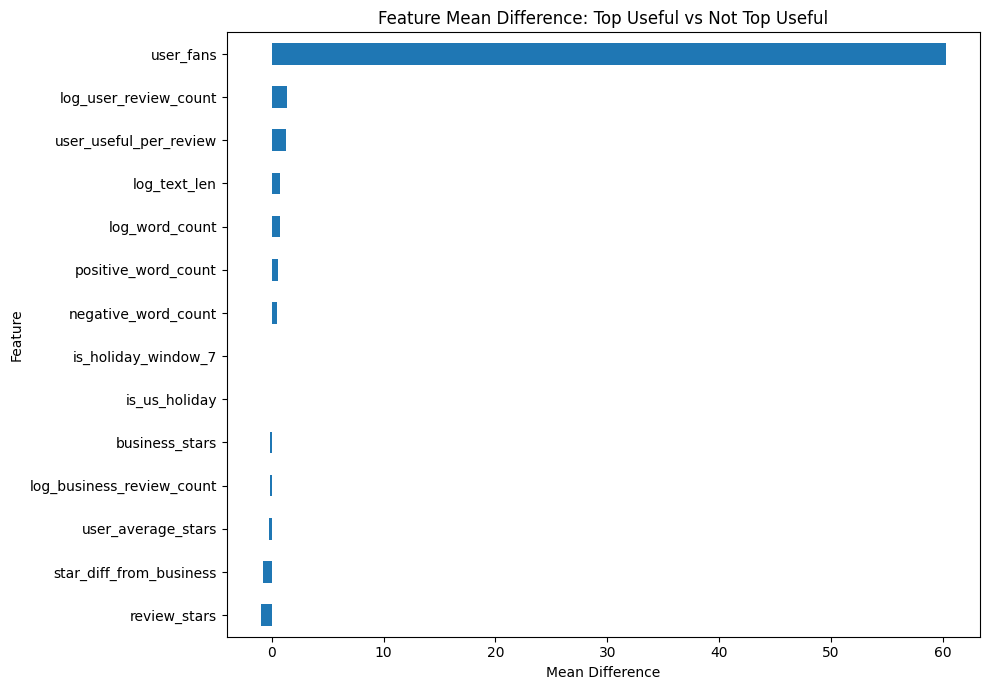

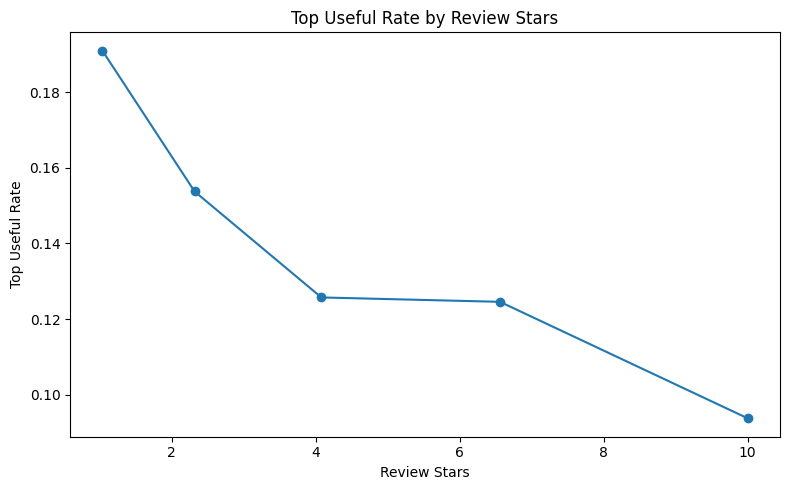

In [15]:
# ============================================================
# 14. Feature Insight Outputs
# ============================================================

def create_feature_insight_outputs(train_features, y, output_dir):
    insight_cols = [
        "log_text_len",
        "log_word_count",
        "review_stars",
        "business_stars",
        "log_business_review_count",
        "log_user_review_count",
        "user_fans",
        "user_average_stars",
        "positive_word_count",
        "negative_word_count",
        "star_diff_from_business",
        "user_useful_per_review",
        "is_us_holiday",
        "is_holiday_window_7"
    ]

    insight_cols = [c for c in insight_cols if c in train_features.columns]

    temp = train_features[insight_cols].copy()
    temp["top_useful"] = y.values

    summary = temp.groupby("top_useful")[insight_cols].mean().T
    summary.columns = ["mean_when_not_top_useful", "mean_when_top_useful"]
    summary["difference_top_minus_not"] = (
            summary["mean_when_top_useful"] - summary["mean_when_not_top_useful"]
    )
    summary["abs_difference"] = summary["difference_top_minus_not"].abs()
    summary = summary.sort_values("abs_difference", ascending=False)

    summary_path = os.path.join(output_dir, "super_feature_insight_10plus_features.csv")
    summary.to_csv(summary_path)

    print("Saved feature insight summary:", summary_path)
    print(summary)

    plt.figure(figsize=(10, 7))
    summary["difference_top_minus_not"].sort_values().plot(kind="barh")
    plt.title("Feature Mean Difference: Top Useful vs Not Top Useful")
    plt.xlabel("Mean Difference")
    plt.ylabel("Feature")
    plt.tight_layout()
    fig_path = os.path.join(output_dir, "super_feature_mean_difference_10plus_features.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

    if "review_stars" in train_features.columns:
        star_table = temp.groupby("review_stars")["top_useful"].mean().reset_index()
        star_path = os.path.join(output_dir, "super_target_rate_by_review_stars.csv")
        star_table.to_csv(star_path, index=False)

        plt.figure(figsize=(8, 5))
        plt.plot(star_table["review_stars"], star_table["top_useful"], marker="o")
        plt.title("Top Useful Rate by Review Stars")
        plt.xlabel("Review Stars")
        plt.ylabel("Top Useful Rate")
        plt.tight_layout()
        fig_path2 = os.path.join(output_dir, "super_target_rate_by_review_stars.png")
        plt.savefig(fig_path2, dpi=200)
        plt.show()

    return summary


feature_insight_summary = create_feature_insight_outputs(train_fe, y_series, OUTPUT_DIR)

## Evaluate the impact of external holiday features
This section tests whether the added U.S. holiday features improve model performance. It trains one LightGBM model without holiday-related features and another model with the full feature set, then compares their validation results using AUC, FPR, TPR, accuracy, and confusion matrix values.

In [16]:
# ============================================================
# 15. External Feature Improvement Evidence
# ============================================================

holiday_feature_cols = [
    "is_us_holiday",
    "days_to_nearest_holiday",
    "days_since_previous_holiday",
    "days_until_next_holiday",
    "is_holiday_window_3",
    "is_holiday_window_7",
    "is_before_holiday_3",
    "is_after_holiday_3"
]

holiday_feature_cols = [c for c in holiday_feature_cols if c in X_train.columns]


def train_quick_lgb_and_eval(X_tr, y_tr, X_va, y_va, model_name):
    n_pos = (y_tr == 1).sum()
    n_neg = (y_tr == 0).sum()
    spw = n_neg / n_pos

    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=700,
        learning_rate=0.04,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=spw,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(70),
            lgb.log_evaluation(0)
        ]
    )

    val_score = model.predict_proba(X_va)[:, 1]
    metrics = best_tpr_under_fpr(y_va, val_score, fpr_limit=FPR_LIMIT_FINAL)
    metrics["model"] = model_name
    return model, metrics


print("Holiday external columns:", holiday_feature_cols)

if len(holiday_feature_cols) > 0:
    X_train_no_external = X_train.drop(columns=holiday_feature_cols)
    X_val_no_external = X_val.drop(columns=holiday_feature_cols)

    base_lgb_external_model, base_external_metrics = train_quick_lgb_and_eval(
        X_train_no_external,
        y_train,
        X_val_no_external,
        y_val,
        "LGB without external holiday features"
    )

    holiday_lgb_external_model, holiday_external_metrics = train_quick_lgb_and_eval(
        X_train,
        y_train,
        X_val,
        y_val,
        "LGB with external holiday features"
    )

    external_results = pd.DataFrame([base_external_metrics, holiday_external_metrics])
    external_results = external_results[
        ["model", "auc", "fpr", "tpr", "threshold", "accuracy", "tn", "fp", "fn", "tp"]
    ]

    external_path = os.path.join(OUTPUT_DIR, "super_external_holiday_feature_improvement.csv")
    external_results.to_csv(external_path, index=False)

    print("\nExternal feature improvement evidence:")
    print(external_results)
    print("Saved:", external_path)

    del X_train_no_external, X_val_no_external
    gc.collect()

Holiday external columns: ['is_us_holiday', 'days_to_nearest_holiday', 'days_since_previous_holiday', 'days_until_next_holiday', 'is_holiday_window_3', 'is_holiday_window_7', 'is_before_holiday_3', 'is_after_holiday_3']
[LightGBM] [Info] Number of positive: 152918, number of negative: 1108904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.265902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17091
[LightGBM] [Info] Number of data points in the train set: 1261822, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121188 -> initscore=-1.981226
[LightGBM] [Info] Start training from score -1.981226
Training until validation scores don't improve for 70 rounds
Early stopping, best iteration is:
[13]	valid_0's auc: 0.906814	valid_0's binary_logloss: 0.302244
[LightGBM] [Info] Number of positive: 152918, number of

## Initialize score banks and model evaluation tracking
This section sets up the storage system for comparing multiple models in the model zoo. It calculates the class imbalance weight using the ratio of negative to positive samples, initializes dictionaries to store validation and test prediction scores, and creates a metrics list to track each model’s performance. 

In [17]:
# ============================================================
# 16. Score Bank for Model Zoo
# ============================================================

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos

print("Positive:", n_pos)
print("Negative:", n_neg)
print("scale_pos_weight:", scale_pos_weight)

score_bank_val = {}
score_bank_test = {}
model_metrics = []


def add_model_scores(name, val_score, test_score):
    val_score = np.asarray(val_score).astype("float32")
    test_score = np.asarray(test_score).astype("float32")

    score_bank_val[name] = val_score
    score_bank_test[name] = test_score

    metrics = best_tpr_under_fpr(
        y_val,
        val_score,
        fpr_limit=FPR_LIMIT_FINAL
    )

    row = {
        "model": name,
        "auc": metrics["auc"],
        "fpr": metrics["fpr"],
        "tpr": metrics["tpr"],
        "threshold": metrics["threshold"]
    }

    model_metrics.append(row)

    print(
        f"{name:35s} | "
        f"AUC={metrics['auc']:.6f} | "
        f"FPR={metrics['fpr']:.6f} | "
        f"TPR={metrics['tpr']:.6f}"
    )

    return metrics

Positive: 152918
Negative: 1108904
scale_pos_weight: 7.251625053950483


## Train multiple LightGBM models for the model zoo
This section trains a group of LightGBM models with different random seeds and hyperparameter settings. Each configuration changes elements such as learning rate, number of leaves, minimum child samples, subsampling, column sampling, and regularization to create model diversity. After each model is trained, its validation and test predictions are saved into the score bank, and its performance is evaluated using AUC, FPR, and TPR. 

In [18]:
# ============================================================
# 17. Train LightGBM Model Zoo
# ============================================================

def train_lgb_add(name, params, seed=42):
    print("\n" + "=" * 80)
    print("Training LightGBM:", name)
    print("=" * 80)

    params = params.copy()
    n_estimators = params.pop("n_estimators")

    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=n_estimators,
        scale_pos_weight=scale_pos_weight,
        random_state=seed,
        n_jobs=-1,
        **params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(100)
        ]
    )

    val_score = model.predict_proba(X_val)[:, 1]
    test_score = model.predict_proba(X_test_final)[:, 1]

    metrics = add_model_scores(name, val_score, test_score)

    gc.collect()

    return model, metrics


lgb_configs = [
    {
        "name": "lgb_main_seed42",
        "seed": 42,
        "params": {
            "n_estimators": 1700,
            "learning_rate": 0.03,
            "num_leaves": 127,
            "min_child_samples": 100,
            "subsample": 0.85,
            "colsample_bytree": 0.85
        }
    },
    {
        "name": "lgb_main_seed2024",
        "seed": 2024,
        "params": {
            "n_estimators": 1700,
            "learning_rate": 0.03,
            "num_leaves": 127,
            "min_child_samples": 100,
            "subsample": 0.85,
            "colsample_bytree": 0.85
        }
    },
    {
        "name": "lgb_leaves63_lr003",
        "seed": 42,
        "params": {
            "n_estimators": 1700,
            "learning_rate": 0.03,
            "num_leaves": 63,
            "min_child_samples": 80,
            "subsample": 0.85,
            "colsample_bytree": 0.85
        }
    },
    {
        "name": "lgb_leaves191_reg",
        "seed": 77,
        "params": {
            "n_estimators": 2200,
            "learning_rate": 0.025,
            "num_leaves": 191,
            "min_child_samples": 180,
            "subsample": 0.80,
            "colsample_bytree": 0.75,
            "reg_alpha": 1.0,
            "reg_lambda": 5.0
        }
    },
    {
        "name": "lgb_leaves255_safe",
        "seed": 123,
        "params": {
            "n_estimators": 2400,
            "learning_rate": 0.02,
            "num_leaves": 255,
            "min_child_samples": 220,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "reg_alpha": 2.0,
            "reg_lambda": 8.0
        }
    },
    {
        "name": "lgb_small_leaves",
        "seed": 314,
        "params": {
            "n_estimators": 1600,
            "learning_rate": 0.035,
            "num_leaves": 31,
            "min_child_samples": 60,
            "subsample": 0.90,
            "colsample_bytree": 0.90
        }
    },
    {
        "name": "lgb_more_colsample",
        "seed": 888,
        "params": {
            "n_estimators": 1900,
            "learning_rate": 0.025,
            "num_leaves": 127,
            "min_child_samples": 120,
            "subsample": 0.90,
            "colsample_bytree": 0.95,
            "reg_lambda": 2.0
        }
    }
]

lgb_models = {}

if RUN_EXTRA_LGB:
    for cfg in lgb_configs:
        model, metrics = train_lgb_add(
            name=cfg["name"],
            params=cfg["params"],
            seed=cfg["seed"]
        )
        lgb_models[cfg["name"]] = model
else:
    model, metrics = train_lgb_add(
        name=lgb_configs[0]["name"],
        params=lgb_configs[0]["params"],
        seed=lgb_configs[0]["seed"]
    )
    lgb_models[lgb_configs[0]["name"]] = model


Training LightGBM: lgb_main_seed42
[LightGBM] [Info] Number of positive: 152918, number of negative: 1108904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.199658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17364
[LightGBM] [Info] Number of data points in the train set: 1261822, number of used features: 148
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121188 -> initscore=-1.981226
[LightGBM] [Info] Start training from score -1.981226
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.914872	valid_0's binary_logloss: 0.3586
Early stopping, best iteration is:
[18]	valid_0's auc: 0.909419	valid_0's binary_logloss: 0.299056
lgb_main_seed42                     | AUC=0.909419 | FPR=0.097000 | TPR=0.696252

Training LightGBM: lgb_main_seed2024
[LightGBM] [Info] Number of positive: 152918, number of 

## Train multiple XGBoost models for the model zoo
This section trains several XGBoost models using different hyperparameter settings and random seeds. Each model varies parameters such as tree depth, learning rate, number of estimators, child weight, subsampling, column sampling, and regularization to improve model diversity. The function also supports GPU training if available, but automatically retries on CPU if the environment does not support the GPU setup. After each model is trained, its validation and test prediction scores are saved into the score bank, and its AUC, FPR, and TPR are recorded for later model comparison and blending.

In [19]:
# ============================================================
# 18. Train XGBoost Model Zoo
# ============================================================

def train_xgb_add(name, params, seed=42):
    print("\n" + "=" * 80)
    print("Training XGBoost:", name)
    print("=" * 80)

    params = params.copy()

    base_params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "scale_pos_weight": scale_pos_weight,
        "tree_method": "hist",
        "random_state": seed,
        "n_jobs": -1
    }

    if USE_XGB_GPU:
        base_params["device"] = "cuda"

    model = xgb.XGBClassifier(
        **base_params,
        **params
    )

    try:
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=100
        )
    except Exception as e:
        print("XGBoost GPU or parameter issue. Retrying on CPU.")
        print("Original error:", e)

        base_params.pop("device", None)

        model = xgb.XGBClassifier(
            **base_params,
            **params
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=100
        )

    val_score = model.predict_proba(X_val)[:, 1]
    test_score = model.predict_proba(X_test_final)[:, 1]

    metrics = add_model_scores(name, val_score, test_score)

    gc.collect()

    return model, metrics


xgb_configs = [
    {
        "name": "xgb_depth8_main_seed42",
        "seed": 42,
        "params": {
            "n_estimators": 1300,
            "learning_rate": 0.03,
            "max_depth": 8,
            "min_child_weight": 100,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.0,
            "reg_lambda": 1.0
        }
    },
    {
        "name": "xgb_depth8_reg_seed2024",
        "seed": 2024,
        "params": {
            "n_estimators": 1500,
            "learning_rate": 0.025,
            "max_depth": 8,
            "min_child_weight": 120,
            "subsample": 0.90,
            "colsample_bytree": 0.80,
            "reg_alpha": 0.5,
            "reg_lambda": 3.0
        }
    },
    {
        "name": "xgb_depth6_safe",
        "seed": 77,
        "params": {
            "n_estimators": 1300,
            "learning_rate": 0.03,
            "max_depth": 6,
            "min_child_weight": 150,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "reg_alpha": 1.0,
            "reg_lambda": 5.0
        }
    },
    {
        "name": "xgb_depth5_more_reg",
        "seed": 123,
        "params": {
            "n_estimators": 1200,
            "learning_rate": 0.035,
            "max_depth": 5,
            "min_child_weight": 200,
            "subsample": 0.80,
            "colsample_bytree": 0.75,
            "reg_alpha": 2.0,
            "reg_lambda": 8.0
        }
    },
    {
        "name": "xgb_depth9_large",
        "seed": 314,
        "params": {
            "n_estimators": 1100,
            "learning_rate": 0.025,
            "max_depth": 9,
            "min_child_weight": 150,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "reg_alpha": 1.0,
            "reg_lambda": 5.0
        }
    }
]

xgb_models = {}

if RUN_EXTRA_XGB:
    for cfg in xgb_configs:
        model, metrics = train_xgb_add(
            name=cfg["name"],
            params=cfg["params"],
            seed=cfg["seed"]
        )
        xgb_models[cfg["name"]] = model
else:
    model, metrics = train_xgb_add(
        name=xgb_configs[0]["name"],
        params=xgb_configs[0]["params"],
        seed=xgb_configs[0]["seed"]
    )
    xgb_models[xgb_configs[0]["name"]] = model


Training XGBoost: xgb_depth8_main_seed42
[0]	validation_0-auc:0.89802
[100]	validation_0-auc:0.91363
[200]	validation_0-auc:0.91716
[300]	validation_0-auc:0.91877
[400]	validation_0-auc:0.91977
[500]	validation_0-auc:0.92040
[600]	validation_0-auc:0.92086
[700]	validation_0-auc:0.92120
[800]	validation_0-auc:0.92148
[900]	validation_0-auc:0.92166
[1000]	validation_0-auc:0.92183
[1100]	validation_0-auc:0.92194
[1200]	validation_0-auc:0.92201
[1299]	validation_0-auc:0.92207
xgb_depth8_main_seed42              | AUC=0.922066 | FPR=0.096996 | TPR=0.732873

Training XGBoost: xgb_depth8_reg_seed2024
[0]	validation_0-auc:0.89966
[100]	validation_0-auc:0.91287
[200]	validation_0-auc:0.91628
[300]	validation_0-auc:0.91801
[400]	validation_0-auc:0.91916
[500]	validation_0-auc:0.91989
[600]	validation_0-auc:0.92044
[700]	validation_0-auc:0.92082
[800]	validation_0-auc:0.92115
[900]	validation_0-auc:0.92139
[1000]	validation_0-auc:0.92157
[1100]	validation_0-auc:0.92171
[1200]	validation_0-auc:0.

## Train MLP models and create an ensemble
This section trains multiple MLP neural network models using different random seeds. Each MLP pipeline first imputes missing values, standardizes the features, and then trains a neural network classifier with early stopping. The validation and test prediction scores from each seed are saved, evaluated, and later averaged to create an MLP ensemble.

In [20]:
# ============================================================
# 19. Train MLP Ensemble and Individual Seeds
# ============================================================

mlp_val_scores = []
mlp_test_scores = []
mlp_single_results = []

if RUN_EXTRA_MLP:
    for seed in MLP_SEEDS:
        print("\n" + "=" * 80)
        print(f"Training MLP, random_state={seed}")
        print("=" * 80)

        mlp_model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu",
                alpha=0.001,
                learning_rate_init=0.0005,
                max_iter=140,
                early_stopping=True,
                validation_fraction=0.10,
                random_state=seed
            ))
        ])

        mlp_model.fit(X_train, y_train)

        val_score = mlp_model.predict_proba(X_val)[:, 1]
        test_score = mlp_model.predict_proba(X_test_final)[:, 1]

        mlp_val_scores.append(val_score.astype("float32"))
        mlp_test_scores.append(test_score.astype("float32"))

        metrics = add_model_scores(f"mlp_seed_{seed}", val_score, test_score)

        mlp_single_results.append({
            "seed": seed,
            "auc": metrics["auc"],
            "fpr": metrics["fpr"],
            "tpr": metrics["tpr"],
            "threshold": metrics["threshold"]
        })

        gc.collect()

    mlp_val_score = np.mean(mlp_val_scores, axis=0)
    mlp_test_score = np.mean(mlp_test_scores, axis=0)

    mlp_ensemble_metrics = add_model_scores(
        "mlp_ensemble_all_seeds",
        mlp_val_score,
        mlp_test_score
    )

    mlp_single_results_df = pd.DataFrame(mlp_single_results)
    mlp_single_path = os.path.join(OUTPUT_DIR, "super_mlp_single_seed_results.csv")
    mlp_single_results_df.to_csv(mlp_single_path, index=False)
    print("Saved:", mlp_single_path)


Training MLP, random_state=99
mlp_seed_99                         | AUC=0.917133 | FPR=0.096953 | TPR=0.721285

Training MLP, random_state=42
mlp_seed_42                         | AUC=0.917546 | FPR=0.097000 | TPR=0.723221

Training MLP, random_state=21
mlp_seed_21                         | AUC=0.917117 | FPR=0.096960 | TPR=0.721520

Training MLP, random_state=1
mlp_seed_1                          | AUC=0.916778 | FPR=0.097000 | TPR=0.719323

Training MLP, random_state=123
mlp_seed_123                        | AUC=0.917902 | FPR=0.096996 | TPR=0.722854
mlp_ensemble_all_seeds              | AUC=0.919253 | FPR=0.097000 | TPR=0.726961
Saved: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\super_mlp_single_seed_results.csv


## Summarize and rank all model zoo results
This section compiles the performance results from all trained models into a single summary table. It ranks models primarily by TPR and then by AUC, allowing easy comparison of which models perform best under the FPR constraint.

In [21]:
# ============================================================
# 20. Model Zoo Summary
# ============================================================

model_metrics_df = pd.DataFrame(model_metrics)

model_metrics_df = model_metrics_df.sort_values(
    ["tpr", "auc"],
    ascending=False
).reset_index(drop=True)

model_zoo_path = os.path.join(OUTPUT_DIR, "super_model_zoo_results.csv")
model_metrics_df.to_csv(model_zoo_path, index=False)

print("\nModel zoo results:")
print(model_metrics_df)
print("Saved:", model_zoo_path)


Model zoo results:
                      model       auc       fpr       tpr  threshold
0   xgb_depth8_reg_seed2024  0.922056  0.097000  0.733501   0.655504
1    xgb_depth8_main_seed42  0.922066  0.096996  0.732873   0.654688
2          xgb_depth9_large  0.921896  0.096996  0.732062   0.656245
3           xgb_depth6_safe  0.921106  0.096996  0.731251   0.671381
4       xgb_depth5_more_reg  0.920427  0.097000  0.730126   0.676651
5    mlp_ensemble_all_seeds  0.919253  0.097000  0.726961   0.223167
6               mlp_seed_42  0.917546  0.097000  0.723221   0.206420
7              mlp_seed_123  0.917902  0.096996  0.722854   0.238637
8               mlp_seed_21  0.917117  0.096960  0.721520   0.244933
9               mlp_seed_99  0.917133  0.096953  0.721285   0.207270
10               mlp_seed_1  0.916778  0.097000  0.719323   0.220869
11        lgb_leaves191_reg  0.910682  0.097000  0.700594   0.372000
12       lgb_leaves255_safe  0.910878  0.097000  0.700332   0.372416
13          lg

## Perform advanced Top-K blend search for ensemble optimization
This section searches for the best ensemble blend by combining predictions from the top-performing models in the model zoo. It first selects the top K models based on validation performance, then evaluates multiple blending strategies including single-model baselines, equal-weight averaging, and thousands of randomly generated weighted blends using Dirichlet distributions. Candidate blends are first screened on a validation sample for speed, then the best candidates are fully evaluated on the entire validation set. The final output identifies the strongest blend combinations under the FPR constraint and saves both sample-search and full-evaluation results for later selection.

In [22]:
# ============================================================
# 21. Advanced Top-K Blend Search
# ============================================================

def evaluate_blend_candidate(y_true, score, fpr_limit):
    return best_tpr_under_fpr(y_true, score, fpr_limit=fpr_limit)


def advanced_topk_blend_search(
        model_metrics_df,
        score_bank_val,
        score_bank_test,
        y_val,
        top_k=12,
        search_sample_size=200000,
        random_trials=30000,
        top_eval=300,
        random_state=42,
        fpr_limit=0.097
):
    top_k = min(top_k, len(model_metrics_df))

    top_model_names = model_metrics_df.head(top_k)["model"].tolist()

    print("\nTop models used for blend:")
    for name in top_model_names:
        print(name)

    val_matrix = np.column_stack([score_bank_val[name] for name in top_model_names]).astype("float32")
    test_matrix = np.column_stack([score_bank_test[name] for name in top_model_names]).astype("float32")

    rng = np.random.default_rng(random_state)

    # sample validation rows for fast blend search
    if search_sample_size < len(y_val):
        sample_idx, _ = train_test_split(
            np.arange(len(y_val)),
            train_size=search_sample_size,
            random_state=random_state,
            stratify=y_val
        )
    else:
        sample_idx = np.arange(len(y_val))

    y_sub = pd.Series(y_val).reset_index(drop=True).iloc[sample_idx].values
    val_sub = val_matrix[sample_idx, :]

    candidates = []

    # include single models
    for i, name in enumerate(top_model_names):
        w = np.zeros(top_k)
        w[i] = 1.0

        score_sub = val_sub @ w
        metrics = evaluate_blend_candidate(y_sub, score_sub, fpr_limit)

        candidates.append({
            "stage": "single",
            "auc_sub": metrics["auc"],
            "fpr_sub": metrics["fpr"],
            "tpr_sub": metrics["tpr"],
            "threshold_sub": metrics["threshold"],
            **{f"w_{top_model_names[j]}": w[j] for j in range(top_k)}
        })

    # equal weight
    w_equal = np.ones(top_k) / top_k
    score_sub = val_sub @ w_equal
    metrics = evaluate_blend_candidate(y_sub, score_sub, fpr_limit)

    candidates.append({
        "stage": "equal",
        "auc_sub": metrics["auc"],
        "fpr_sub": metrics["fpr"],
        "tpr_sub": metrics["tpr"],
        "threshold_sub": metrics["threshold"],
        **{f"w_{top_model_names[j]}": w_equal[j] for j in range(top_k)}
    })

    # random Dirichlet blends
    alphas = [0.15, 0.25, 0.5, 0.8, 1.0, 2.0]

    trials_per_alpha = max(1, random_trials // len(alphas))

    for alpha in alphas:
        print("Random blend search alpha:", alpha)

        for _ in range(trials_per_alpha):
            w = rng.dirichlet(np.ones(top_k) * alpha)

            score_sub = val_sub @ w
            metrics = evaluate_blend_candidate(y_sub, score_sub, fpr_limit)

            candidates.append({
                "stage": f"dirichlet_{alpha}",
                "auc_sub": metrics["auc"],
                "fpr_sub": metrics["fpr"],
                "tpr_sub": metrics["tpr"],
                "threshold_sub": metrics["threshold"],
                **{f"w_{top_model_names[j]}": w[j] for j in range(top_k)}
            })

    candidates_df = pd.DataFrame(candidates)

    candidates_df = candidates_df.sort_values(
        ["tpr_sub", "auc_sub"],
        ascending=False
    ).reset_index(drop=True)

    # evaluate top candidates on full validation
    full_results = []

    top_candidates = candidates_df.head(top_eval)

    for idx, row in top_candidates.iterrows():
        w = np.array([row[f"w_{name}"] for name in top_model_names])
        score_full = val_matrix @ w

        metrics = evaluate_blend_candidate(y_val, score_full, fpr_limit)

        full_results.append({
            "rank_from_sub": idx,
            "stage": row["stage"],
            "auc": metrics["auc"],
            "fpr": metrics["fpr"],
            "tpr": metrics["tpr"],
            "threshold": metrics["threshold"],
            **{f"w_{top_model_names[j]}": w[j] for j in range(top_k)}
        })

    full_results_df = pd.DataFrame(full_results)

    full_results_df = full_results_df.sort_values(
        ["tpr", "auc"],
        ascending=False
    ).reset_index(drop=True)

    return top_model_names, val_matrix, test_matrix, candidates_df, full_results_df


top_model_names, val_matrix, test_matrix, blend_candidates_df, advanced_blend_df = advanced_topk_blend_search(
    model_metrics_df=model_metrics_df,
    score_bank_val=score_bank_val,
    score_bank_test=score_bank_test,
    y_val=y_val,
    top_k=TOP_K_FOR_BLEND,
    search_sample_size=BLEND_SEARCH_SAMPLE_SIZE,
    random_trials=RANDOM_BLEND_TRIALS,
    top_eval=RANDOM_BLEND_TOP_EVAL,
    random_state=RANDOM_STATE,
    fpr_limit=FPR_LIMIT_FINAL
)

blend_candidates_path = os.path.join(OUTPUT_DIR, "super_blend_candidates_sample_search.csv")
advanced_blend_path = os.path.join(OUTPUT_DIR, "super_advanced_blend_full_eval.csv")

blend_candidates_df.to_csv(blend_candidates_path, index=False)
advanced_blend_df.to_csv(advanced_blend_path, index=False)

print("\nTop 20 advanced blend full-validation results:")
print(advanced_blend_df.head(20))

print("Saved sample blend candidates:", blend_candidates_path)
print("Saved full eval blend results:", advanced_blend_path)


Top models used for blend:
xgb_depth8_reg_seed2024
xgb_depth8_main_seed42
xgb_depth9_large
xgb_depth6_safe
xgb_depth5_more_reg
mlp_ensemble_all_seeds
mlp_seed_42
mlp_seed_123
mlp_seed_21
mlp_seed_99
mlp_seed_1
lgb_leaves191_reg
Random blend search alpha: 0.15
Random blend search alpha: 0.25
Random blend search alpha: 0.5
Random blend search alpha: 0.8
Random blend search alpha: 1.0
Random blend search alpha: 2.0

Top 20 advanced blend full-validation results:
    rank_from_sub           stage       auc       fpr       tpr  threshold  \
0              58  dirichlet_0.15  0.922120  0.096982  0.734992   0.576932   
1              38  dirichlet_0.15  0.922058  0.097000  0.734861   0.547553   
2              32  dirichlet_0.15  0.922044  0.097000  0.734861   0.532880   
3               7  dirichlet_0.15  0.921943  0.096993  0.734861   0.505403   
4              11  dirichlet_0.25  0.921973  0.096982  0.734835   0.519666   
5               1  dirichlet_0.15  0.921889  0.096996  0.734835   0

## Refine the best blend weights locally
This section further improves the best blending result by making small random adjustments around the current best model weights. It adds noise to the best weight combination, clips negative weights to zero, normalizes the weights, and evaluates each refined blend on the validation set. The refined results are combined with the previous blend results, ranked by TPR and AUC, and saved for final ensemble selection.

In [23]:
# ============================================================
# 22. Local Blend Refinement Around Best Weights
# ============================================================

def local_refine_blend(
        advanced_blend_df,
        top_model_names,
        val_matrix,
        y_val,
        n_rounds=5000,
        noise_scale=0.06,
        random_state=42,
        fpr_limit=0.097
):
    rng = np.random.default_rng(random_state)

    best_row = advanced_blend_df.iloc[0]
    best_w = np.array([best_row[f"w_{name}"] for name in top_model_names], dtype=float)

    refined_results = []

    for i in range(n_rounds):
        noise = rng.normal(0, noise_scale, size=len(best_w))
        w = best_w + noise
        w = np.clip(w, 0, None)

        if w.sum() == 0:
            continue

        w = w / w.sum()

        score = val_matrix @ w
        metrics = best_tpr_under_fpr(y_val, score, fpr_limit=fpr_limit)

        refined_results.append({
            "stage": "local_refine",
            "auc": metrics["auc"],
            "fpr": metrics["fpr"],
            "tpr": metrics["tpr"],
            "threshold": metrics["threshold"],
            **{f"w_{top_model_names[j]}": w[j] for j in range(len(top_model_names))}
        })

    refined_df = pd.DataFrame(refined_results)

    combined_df = pd.concat(
        [advanced_blend_df, refined_df],
        ignore_index=True
    )

    combined_df = combined_df.sort_values(
        ["tpr", "auc"],
        ascending=False
    ).reset_index(drop=True)

    return combined_df


advanced_blend_refined_df = local_refine_blend(
    advanced_blend_df=advanced_blend_df,
    top_model_names=top_model_names,
    val_matrix=val_matrix,
    y_val=y_val,
    n_rounds=5000,
    noise_scale=0.04,
    random_state=RANDOM_STATE + 999,
    fpr_limit=FPR_LIMIT_FINAL
)

advanced_refined_path = os.path.join(OUTPUT_DIR, "super_advanced_blend_refined_results.csv")
advanced_blend_refined_df.to_csv(advanced_refined_path, index=False)

print("\nTop 20 refined blend results:")
print(advanced_blend_refined_df.head(20))
print("Saved:", advanced_refined_path)


Top 20 refined blend results:
    rank_from_sub         stage       auc       fpr       tpr  threshold  \
0             NaN  local_refine  0.922122  0.096996  0.735227   0.567600   
1             NaN  local_refine  0.922097  0.096964  0.735227   0.559800   
2             NaN  local_refine  0.922132  0.096967  0.735149   0.579925   
3             NaN  local_refine  0.922122  0.096982  0.735149   0.567279   
4             NaN  local_refine  0.922122  0.096982  0.735149   0.574909   
5             NaN  local_refine  0.922147  0.096993  0.735123   0.575546   
6             NaN  local_refine  0.922082  0.096982  0.735123   0.561780   
7             NaN  local_refine  0.922145  0.096996  0.735096   0.577459   
8             NaN  local_refine  0.922112  0.096982  0.735096   0.565939   
9             NaN  local_refine  0.922107  0.097000  0.735096   0.578357   
10            NaN  local_refine  0.922100  0.097000  0.735096   0.574692   
11            NaN  local_refine  0.922087  0.096953  0.73

## Export the final super blend submission
This section selects the best refined blend, applies its optimized model weights to validation and test predictions, and evaluates the final validation performance under the FPR constraint. It then converts test scores into binary predictions using the selected threshold and exports the final submission file. The code also saves detailed test scores, prints the selected model weights, compares the new validation result with the previous best submission, and recommends whether to use the new submission or keep the old one.

In [ ]:
# ============================================================
# 23. Export Final Super Blend Submission
# ============================================================

best_adv = advanced_blend_refined_df.iloc[0]

best_weights = np.array([
    best_adv[f"w_{name}"] for name in top_model_names
])

best_threshold = best_adv["threshold"]

super_val_score = val_matrix @ best_weights
super_test_score = test_matrix @ best_weights

super_metrics = best_tpr_under_fpr(
    y_val,
    super_val_score,
    fpr_limit=FPR_LIMIT_FINAL
)

print_metrics("SUPER ADVANCED BLEND VALIDATION METRICS", super_metrics)

super_pred = (super_test_score >= best_threshold).astype(int)

super_submission = pd.DataFrame({
    "top_useful": super_pred
})

super_submission_path = os.path.join(
    OUTPUT_DIR,
    "group_7_yelp.csv"
)

super_submission.to_csv(
    super_submission_path,
    index=False,
    header=False
)

super_score_path = os.path.join(
    OUTPUT_DIR,
    "super_advanced_blend_test_scores.csv"
)

pd.DataFrame({
    "final_score": super_test_score,
    "prediction": super_pred
}).to_csv(super_score_path, index=False)

print("\n" + "=" * 80)
print("SUPER ADVANCED BLEND SAVED")
print("=" * 80)

print("Submission:", super_submission_path)
print("Scores:", super_score_path)

print("\nSelected models and weights:")
for name, w in zip(top_model_names, best_weights):
    print(f"{name:35s}: {w:.6f}")

print("\nSuper validation result:")
print("AUC:", super_metrics["auc"])
print("FPR:", super_metrics["fpr"])
print("TPR:", super_metrics["tpr"])
print("Threshold:", best_threshold)

print("\nPositive predictions:", super_pred.sum())
print("Positive ratio:", super_pred.mean())

print("\nPrevious best:")
print("FPR:", CURRENT_BEST_FPR)
print("TPR:", CURRENT_BEST_TPR)

if super_metrics["fpr"] <= FPR_LIMIT and super_metrics["tpr"] > CURRENT_BEST_TPR:
    print("\nUSE NEW SUBMISSION:")
    print(super_submission_path)
else:
    print("\nKEEP OLD SUBMISSION unless leaderboard confirms improvement.")
    print("New validation did not beat previous TPR safely.")


SUPER ADVANCED BLEND VALIDATION METRICS
auc: 0.9221223637567184
fpr: 0.09699632431184553
tpr: 0.7352271835517539
threshold: 0.5675998884507351
accuracy: 0.882671434368026
tn: 250337
fp: 26890
fn: 10122
tp: 28107

SUPER ADVANCED BLEND SAVED
Submission: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\group_5_yelp_super_advanced_blend.csv
Scores: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\super_advanced_blend_test_scores.csv

Selected models and weights:
xgb_depth8_reg_seed2024            : 0.752208
xgb_depth8_main_seed42             : 0.000000
xgb_depth9_large                   : 0.050292
xgb_depth6_safe                    : 0.000000
xgb_depth5_more_reg                : 0.000000
mlp_ensemble_all_seeds             : 0.000000
mlp_seed_42                        : 0.149907
mlp_seed_123                       : 0.000000
mlp_seed_21                        : 0.000000
mlp_seed_99                        : 0.000000
mlp_seed_1                         : 0.040934
lgb_leaves191_re

## Save final performance summary tables
This section stores the key results of the final super blend into a summary table for documentation and reporting. It records previous benchmark performance, final validation metrics (FPR, TPR, AUC, threshold), and prediction distribution statistics such as total positive predictions and positive ratio. The summary is then saved as a final reference file for easy comparison and project reporting.

In [25]:
# ============================================================
# 24. Save Main Final Tables
# ============================================================

final_summary = {
    "previous_best_fpr": CURRENT_BEST_FPR,
    "previous_best_tpr": CURRENT_BEST_TPR,
    "super_fpr": super_metrics["fpr"],
    "super_tpr": super_metrics["tpr"],
    "super_auc": super_metrics["auc"],
    "super_threshold": best_threshold,
    "positive_predictions": int(super_pred.sum()),
    "positive_ratio": float(super_pred.mean())
}

final_summary_path = os.path.join(OUTPUT_DIR, "super_final_summary.csv")
pd.DataFrame([final_summary]).to_csv(final_summary_path, index=False)

print("Saved final summary:", final_summary_path)
print(pd.DataFrame([final_summary]))

Saved final summary: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\super_final_summary.csv
   previous_best_fpr  previous_best_tpr  super_fpr  super_tpr  super_auc  \
0           0.096982           0.735672   0.096996   0.735227   0.922122   

   super_threshold  positive_predictions  positive_ratio  
0           0.5676                124289        0.177556  


## Compare 6+ different model types for report analysis
This section evaluates a broad set of machine learning models for reporting purposes, including Logistic Regression, Decision Tree, Random Forest, AdaBoost, Naive Bayes, MLP Neural Network, LightGBM, and XGBoost. Using sampled training and validation subsets for efficiency, each model is trained and evaluated under the same FPR constraint to compare AUC, TPR, threshold, accuracy, and confusion matrix metrics.

Model comparison train sample: (200000, 161)
Model comparison val sample: (140000, 161)

Training model for comparison: Logistic Regression
Logistic Regression AUC: 0.9036828582872555 FPR: 0.09699757790529447 TPR: 0.6784156548390899

Training model for comparison: Decision Tree
Decision Tree AUC: 0.8885590439831517 FPR: 0.09682689337906594 TPR: 0.6506542496758222

Training model for comparison: Random Forest
Random Forest AUC: 0.9104038085858182 FPR: 0.09698945007071216 TPR: 0.7018743369091124

Training model for comparison: AdaBoost
AdaBoost AUC: 0.8784428139078031 FPR: 0.0964042459807858 TPR: 0.6303194624543204

Training model for comparison: Naive Bayes
Naive Bayes AUC: 0.852945314164051 FPR: 0.09697319440154754 TPR: 0.571083343156902

Training model for comparison: MLP Neural Network
MLP Neural Network AUC: 0.9090168625519514 FPR: 0.09699757790529447 TPR: 0.6958623128610162

Training model for comparison: LightGBM
[LightGBM] [Info] Number of positive: 24238, number of negative: 175

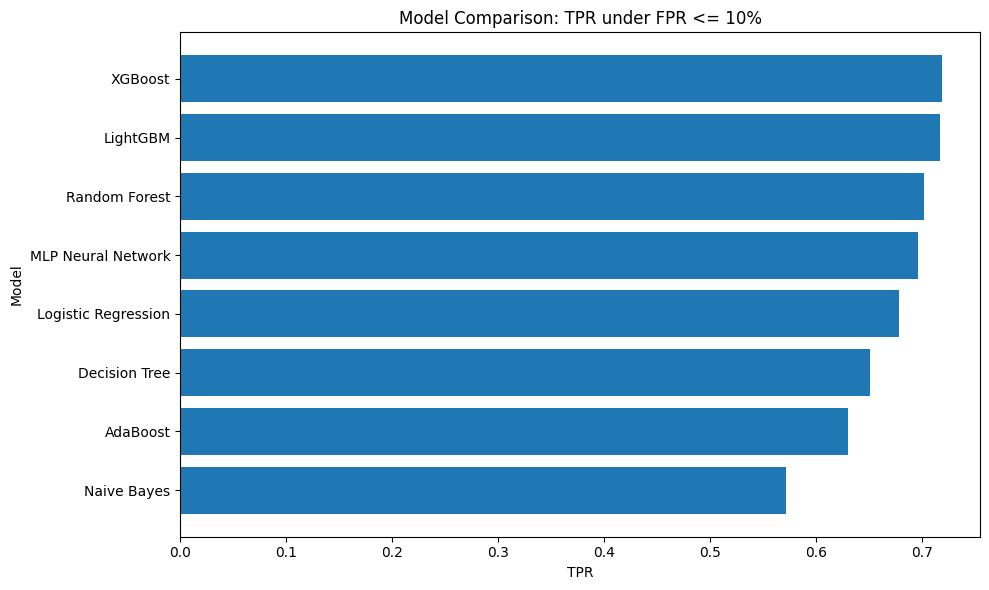

Saved chart: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\super_six_plus_model_comparison_tpr.png


In [26]:
# ============================================================
# 25. Report Block: Compare 6+ Different Model Types
# ============================================================

if RUN_REPORT_BLOCKS:

    compare_size = min(MODEL_COMPARE_SAMPLE_SIZE, len(X_train))

    X_cmp_train, _, y_cmp_train, _ = train_test_split(
        X_train,
        y_train,
        train_size=compare_size,
        random_state=RANDOM_STATE,
        stratify=y_train
    )

    val_size = min(140000, len(X_val))

    X_cmp_val, _, y_cmp_val, _ = train_test_split(
        X_val,
        y_val,
        train_size=val_size,
        random_state=RANDOM_STATE,
        stratify=y_val
    )

    print("Model comparison train sample:", X_cmp_train.shape)
    print("Model comparison val sample:", X_cmp_val.shape)

    compare_models = {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=0.5,
                penalty="l2",
                class_weight="balanced",
                solver="saga",
                max_iter=500,
                n_jobs=N_JOBS,
                random_state=RANDOM_STATE
            ))
        ]),

        "Decision Tree": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(
                max_depth=12,
                min_samples_leaf=80,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]),

        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                max_depth=24,
                min_samples_leaf=20,
                max_features="sqrt",
                class_weight="balanced_subsample",
                n_jobs=N_JOBS,
                random_state=RANDOM_STATE
            ))
        ]),

        "AdaBoost": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", AdaBoostClassifier(
                estimator=DecisionTreeClassifier(
                    max_depth=3,
                    min_samples_leaf=80,
                    class_weight="balanced",
                    random_state=RANDOM_STATE
                ),
                n_estimators=220,
                learning_rate=0.06,
                random_state=RANDOM_STATE
            ))
        ]),

        "Naive Bayes": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ]),

        "MLP Neural Network": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                alpha=0.001,
                learning_rate_init=0.0005,
                max_iter=90,
                early_stopping=True,
                validation_fraction=0.10,
                random_state=99
            ))
        ]),

        "LightGBM": lgb.LGBMClassifier(
            objective="binary",
            n_estimators=700,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=100,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "XGBoost": xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            n_estimators=700,
            learning_rate=0.04,
            max_depth=6,
            min_child_weight=100,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=scale_pos_weight,
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

    compare_results = []

    for name, model in compare_models.items():
        print("\nTraining model for comparison:", name)

        model.fit(X_cmp_train, y_cmp_train)
        val_score = get_model_score(model, X_cmp_val)

        metrics = best_tpr_under_fpr(
            y_cmp_val,
            val_score,
            fpr_limit=FPR_LIMIT_FINAL
        )

        metrics["model"] = name
        compare_results.append(metrics)

        print(name, "AUC:", metrics["auc"], "FPR:", metrics["fpr"], "TPR:", metrics["tpr"])

        gc.collect()

    compare_results_df = pd.DataFrame(compare_results)
    compare_results_df = compare_results_df[
        ["model", "auc", "fpr", "tpr", "threshold", "accuracy", "tn", "fp", "fn", "tp"]
    ].sort_values(["tpr", "auc"], ascending=False)

    compare_path = os.path.join(OUTPUT_DIR, "super_six_plus_model_comparison.csv")
    compare_results_df.to_csv(compare_path, index=False)

    print("\nSix-plus model comparison:")
    print(compare_results_df)
    print("Saved:", compare_path)

    plt.figure(figsize=(10, 6))
    plot_df = compare_results_df.sort_values("tpr")
    plt.barh(plot_df["model"], plot_df["tpr"])
    plt.title("Model Comparison: TPR under FPR <= 10%")
    plt.xlabel("TPR")
    plt.ylabel("Model")
    plt.tight_layout()
    fig_path = os.path.join(OUTPUT_DIR, "super_six_plus_model_comparison_tpr.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("Saved chart:", fig_path)

## Run 5-fold cross-validation for LightGBM
This section evaluates the stability of the LightGBM model using 5-fold stratified cross-validation. It samples the training data for efficiency, splits it into five folds while preserving the class distribution, and trains one LightGBM model per fold. For each fold, it records AUC, FPR, TPR, threshold, confusion matrix results, and the best iteration from early stopping. The final CV results are saved and summarized to show the model’s average performance and consistency across folds.

In [27]:
# ============================================================
# 26. Report Block: 5-Fold CV for LightGBM
# ============================================================

if RUN_REPORT_BLOCKS:

    cv_size = min(CURVE_SAMPLE_SIZE, len(X_train))

    X_cv_pool, _, y_cv_pool, _ = train_test_split(
        X_train,
        y_train,
        train_size=cv_size,
        random_state=RANDOM_STATE,
        stratify=y_train
    )

    print("CV sample:", X_cv_pool.shape)

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    cv_results = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv_pool, y_cv_pool), start=1):
        print("\nCV Fold:", fold)

        X_tr = X_cv_pool.iloc[tr_idx]
        X_va = X_cv_pool.iloc[va_idx]
        y_tr = y_cv_pool.iloc[tr_idx]
        y_va = y_cv_pool.iloc[va_idx]

        n_pos_fold = (y_tr == 1).sum()
        n_neg_fold = (y_tr == 0).sum()
        spw_fold = n_neg_fold / n_pos_fold

        cv_model = lgb.LGBMClassifier(
            objective="binary",
            n_estimators=700,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=100,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=spw_fold,
            random_state=RANDOM_STATE + fold,
            n_jobs=-1
        )

        cv_model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            callbacks=[
                lgb.early_stopping(70),
                lgb.log_evaluation(0)
            ]
        )

        val_score = cv_model.predict_proba(X_va)[:, 1]
        metrics = best_tpr_under_fpr(y_va, val_score, fpr_limit=FPR_LIMIT_FINAL)
        metrics["fold"] = fold
        metrics["best_iteration"] = cv_model.best_iteration_

        cv_results.append(metrics)

        print("Fold", fold, "AUC:", metrics["auc"], "FPR:", metrics["fpr"], "TPR:", metrics["tpr"])

        gc.collect()

    cv_results_df = pd.DataFrame(cv_results)
    cv_path = os.path.join(OUTPUT_DIR, "super_lightgbm_5fold_cv_results.csv")
    cv_results_df.to_csv(cv_path, index=False)

    print("\n5-fold CV results:")
    print(cv_results_df)
    print("\nCV mean:")
    print(cv_results_df[["auc", "fpr", "tpr"]].mean())
    print("Saved:", cv_path)

CV sample: (400000, 161)

CV Fold: 1
[LightGBM] [Info] Number of positive: 38780, number of negative: 281220
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.187145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17359
[LightGBM] [Info] Number of data points in the train set: 320000, number of used features: 148
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121188 -> initscore=-1.981233
[LightGBM] [Info] Start training from score -1.981233
Training until validation scores don't improve for 70 rounds
Early stopping, best iteration is:
[14]	valid_0's auc: 0.906594	valid_0's binary_logloss: 0.300438
Fold 1 AUC: 0.9065941556716024 FPR: 0.09686366545764881 TPR: 0.6848891181021145

CV Fold: 2
[LightGBM] [Info] Number of positive: 38780, number of negative: 281220
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.187517 seconds.
You can set `force_col_wise=true` to 

## Generate a safe learning curve for LightGBM
This section evaluates how LightGBM performance changes as the training sample size increases. It trains models using different fractions of the training data, from 10% to 100%, while safely handling cases where the full dataset is used. For each fraction, it records AUC, FPR, TPR, threshold, and best iteration.


Learning curve fraction: 0.1
Training sample size: 40000
[LightGBM] [Info] Number of positive: 4848, number of negative: 35152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023018 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17052
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 148
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121200 -> initscore=-1.981115
[LightGBM] [Info] Start training from score -1.981115
Training until validation scores don't improve for 70 rounds
Early stopping, best iteration is:
[15]	valid_0's auc: 0.901825	valid_0's binary_logloss: 0.300069
AUC: 0.9018248343342529
FPR: 0.096978288550538
TPR: 0.6750372753668681

Learning curve fraction: 0.3
Training sample size: 120000
[LightGBM] [Info] Number of positive: 14543, number of negative: 105457
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was

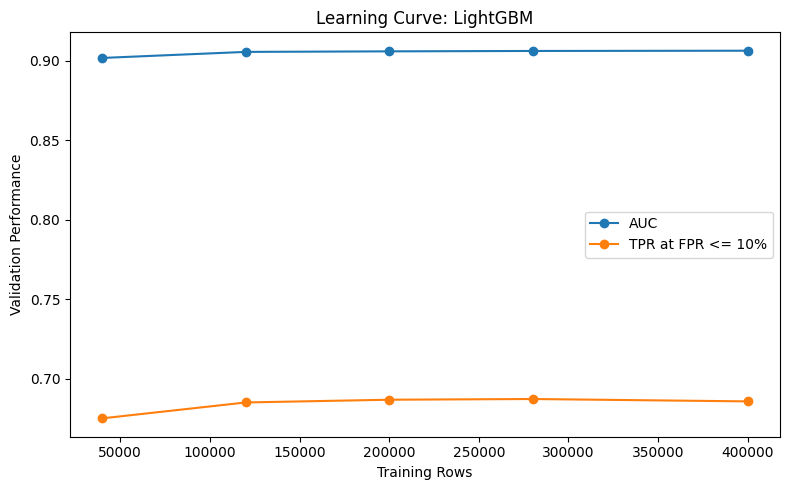

Saved chart: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\super_learning_curve_lgb.png


In [ ]:
# ============================================================
# 27. Report Block: Learning Curve
# ============================================================

if RUN_REPORT_BLOCKS:

    lc_size = min(CURVE_SAMPLE_SIZE, len(X_train))

    # If lc_size equals the full X_train, use the entire dataset directly without train_test_split
    if lc_size >= len(X_train):
        X_lc_pool = X_train.copy()
        y_lc_pool = y_train.copy()
    else:
        X_lc_pool, _, y_lc_pool, _ = train_test_split(
            X_train,
            y_train,
            train_size=lc_size,
            random_state=RANDOM_STATE,
            stratify=y_train
        )

    learning_fracs = [0.10, 0.30, 0.50, 0.70, 1.00]
    learning_results = []

    for frac in learning_fracs:
        n_sample = int(len(X_lc_pool) * frac)

        # Key fix: If frac = 1.00, use the entire dataset directly
        if n_sample >= len(X_lc_pool):
            X_lc_train = X_lc_pool.copy()
            y_lc_train = y_lc_pool.copy()
        else:
            X_lc_train, _, y_lc_train, _ = train_test_split(
                X_lc_pool,
                y_lc_pool,
                train_size=n_sample,
                random_state=RANDOM_STATE,
                stratify=y_lc_pool
            )

        n_pos_lc = (y_lc_train == 1).sum()
        n_neg_lc = (y_lc_train == 0).sum()
        spw_lc = n_neg_lc / n_pos_lc

        print("\nLearning curve fraction:", frac)
        print("Training sample size:", len(X_lc_train))

        lc_model = lgb.LGBMClassifier(
            objective="binary",
            n_estimators=700,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=100,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=spw_lc,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        lc_model.fit(
            X_lc_train,
            y_lc_train,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[
                lgb.early_stopping(70),
                lgb.log_evaluation(0)
            ]
        )

        val_score = lc_model.predict_proba(X_val)[:, 1]

        metrics = best_tpr_under_fpr(
            y_val,
            val_score,
            fpr_limit=FPR_LIMIT_FINAL
        )

        learning_results.append({
            "training_fraction": frac,
            "training_rows": len(X_lc_train),
            "auc": metrics["auc"],
            "fpr": metrics["fpr"],
            "tpr": metrics["tpr"],
            "threshold": metrics["threshold"],
            "best_iteration": lc_model.best_iteration_
        })

        print("AUC:", metrics["auc"])
        print("FPR:", metrics["fpr"])
        print("TPR:", metrics["tpr"])

        gc.collect()

    learning_results_df = pd.DataFrame(learning_results)

    learning_path = os.path.join(
        OUTPUT_DIR,
        "super_learning_curve_results.csv"
    )

    learning_results_df.to_csv(learning_path, index=False)

    print("\nLearning curve results:")
    print(learning_results_df)
    print("Saved:", learning_path)

    plt.figure(figsize=(8, 5))

    plt.plot(
        learning_results_df["training_rows"],
        learning_results_df["auc"],
        marker="o",
        label="AUC"
    )

    plt.plot(
        learning_results_df["training_rows"],
        learning_results_df["tpr"],
        marker="o",
        label="TPR at FPR <= 10%"
    )

    plt.title("Learning Curve: LightGBM")
    plt.xlabel("Training Rows")
    plt.ylabel("Validation Performance")
    plt.legend()
    plt.tight_layout()

    fig_path = os.path.join(
        OUTPUT_DIR,
        "super_learning_curve_lgb.png"
    )

    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("Saved chart:", fig_path)

## Generate a LightGBM tuning curve for model complexity
This section evaluates how different num_leaves values affect LightGBM performance. It tests several levels of tree complexity, records training AUC and validation AUC, and also saves validation FPR, TPR, and best iteration for each setting. The tuning curve helps compare underfitting and overfitting patterns and supports the final hyperparameter choice for the report.


Tuning num_leaves: 15
[LightGBM] [Info] Number of positive: 36356, number of negative: 263644
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.173805 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17370
[LightGBM] [Info] Number of data points in the train set: 300000, number of used features: 148
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121187 -> initscore=-1.981240
[LightGBM] [Info] Start training from score -1.981240
Training until validation scores don't improve for 70 rounds
Early stopping, best iteration is:
[12]	valid_0's auc: 0.89833	valid_0's binary_logloss: 0.309864
train_auc: 0.9004258495907921 val_auc: 0.8983299828466121 val_tpr: 0.6630084990510768

Tuning num_leaves: 31
[LightGBM] [Info] Number of positive: 36356, number of negative: 263644
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.156311 seconds.
You can set `force_col_wise=true` t

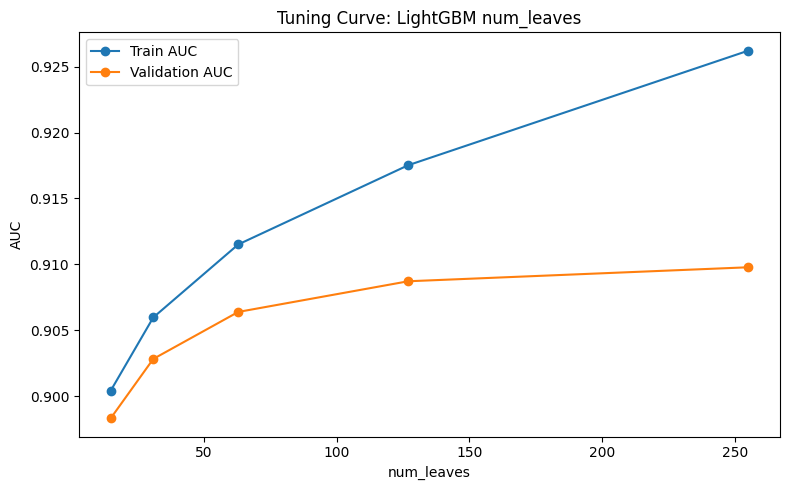

Saved chart: C:\Users\laoti\Desktop\Grad School\BUDT758T\Data&Sample\super_lgb_num_leaves_tuning_curve.png


In [30]:
# ============================================================
# 28. Report Block: Tuning / Fitting Curve
# ============================================================

if RUN_REPORT_BLOCKS:

    tune_size = min(CURVE_SAMPLE_SIZE, len(X_train))

    X_tune_pool, _, y_tune_pool, _ = train_test_split(
        X_train,
        y_train,
        train_size=tune_size,
        random_state=RANDOM_STATE,
        stratify=y_train
    )

    X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
        X_tune_pool,
        y_tune_pool,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_tune_pool
    )

    num_leaves_grid = [15, 31, 63, 127, 255]
    tuning_results = []

    for nl in num_leaves_grid:
        print("\nTuning num_leaves:", nl)

        n_pos_tune = (y_tune_train == 1).sum()
        n_neg_tune = (y_tune_train == 0).sum()
        spw_tune = n_neg_tune / n_pos_tune

        tune_model = lgb.LGBMClassifier(
            objective="binary",
            n_estimators=800,
            learning_rate=0.04,
            num_leaves=nl,
            min_child_samples=100,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=spw_tune,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        tune_model.fit(
            X_tune_train,
            y_tune_train,
            eval_set=[(X_tune_val, y_tune_val)],
            eval_metric="auc",
            callbacks=[
                lgb.early_stopping(70),
                lgb.log_evaluation(0)
            ]
        )

        train_score = tune_model.predict_proba(X_tune_train)[:, 1]
        val_score = tune_model.predict_proba(X_tune_val)[:, 1]

        train_auc = roc_auc_score(y_tune_train, train_score)
        val_metrics = best_tpr_under_fpr(y_tune_val, val_score, fpr_limit=FPR_LIMIT_FINAL)

        tuning_results.append({
            "num_leaves": nl,
            "train_auc": train_auc,
            "val_auc": val_metrics["auc"],
            "val_fpr": val_metrics["fpr"],
            "val_tpr": val_metrics["tpr"],
            "best_iteration": tune_model.best_iteration_
        })

        print("train_auc:", train_auc, "val_auc:", val_metrics["auc"], "val_tpr:", val_metrics["tpr"])

        gc.collect()

    tuning_results_df = pd.DataFrame(tuning_results)
    tuning_path = os.path.join(OUTPUT_DIR, "super_lgb_num_leaves_tuning_curve.csv")
    tuning_results_df.to_csv(tuning_path, index=False)

    print("\nTuning curve results:")
    print(tuning_results_df)
    print("Saved:", tuning_path)

    plt.figure(figsize=(8, 5))
    plt.plot(
        tuning_results_df["num_leaves"],
        tuning_results_df["train_auc"],
        marker="o",
        label="Train AUC"
    )
    plt.plot(
        tuning_results_df["num_leaves"],
        tuning_results_df["val_auc"],
        marker="o",
        label="Validation AUC"
    )
    plt.title("Tuning Curve: LightGBM num_leaves")
    plt.xlabel("num_leaves")
    plt.ylabel("AUC")
    plt.legend()
    plt.tight_layout()
    fig_path = os.path.join(OUTPUT_DIR, "super_lgb_num_leaves_tuning_curve.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("Saved chart:", fig_path)

## Print final FPR and TPR

In [31]:
print("FPR:", super_metrics["fpr"])
print("TPR:", super_metrics["tpr"])

FPR: 0.09699632431184553
TPR: 0.7352271835517539


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

# -----------------------------
# Setup
# -----------------------------
n_splits = 5
skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# -----------------------------
# Numeric columns only
# -----------------------------
numeric_features = X_train.select_dtypes(include=[np.number]).columns

X_train_hgb = X_train[numeric_features].copy()
X_test_hgb = X_test[numeric_features].copy()

# -----------------------------
# Handle missing values
# -----------------------------
imputer = SimpleImputer(strategy="median")

X_train_hgb = imputer.fit_transform(X_train_hgb)
X_test_hgb = imputer.transform(X_test_hgb)

# -----------------------------
# Storage
# -----------------------------
oof_preds = np.zeros(len(X_train_hgb))
test_preds = np.zeros(len(X_test_hgb))

auc_scores = []
tpr_scores = []
fpr_scores = []
threshold_scores = []

# -----------------------------
# Cross Validation
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_hgb, y)):

    X_tr, X_val = X_train_hgb[train_idx], X_train_hgb[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # sample weight for class imbalance
    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_tr
    )

    model = HistGradientBoostingClassifier(
        learning_rate=0.01,
        max_iter=1000,
        max_depth=12,
        min_samples_leaf=20,
        l2_regularization=0.05,
        random_state=42
    )

    model.fit(X_tr, y_tr, sample_weight=sample_weights)

    val_probs = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test_hgb)[:, 1]

    oof_preds[val_idx] = val_probs
    test_preds += test_probs / n_splits

    auc = roc_auc_score(y_val, val_probs)
    auc_scores.append(auc)

    # Best TPR while keeping FPR <= 10%
    fpr, tpr, thresholds = roc_curve(y_val, val_probs)

    valid = fpr <= 0.095

    best_tpr = tpr[valid].max()
    best_idx = np.where(valid)[0][np.argmax(tpr[valid])]

    best_fpr = fpr[best_idx]
    best_threshold = thresholds[best_idx]

    tpr_scores.append(best_tpr)
    fpr_scores.append(best_fpr)
    threshold_scores.append(best_threshold)

    print(
        f"Fold {fold + 1} | "
        f"AUC: {auc:.4f} | "
        f"TPR: {best_tpr:.4f} | "
        f"FPR: {best_fpr:.4f} | "
        f"Threshold: {best_threshold:.4f}"
    )

# -----------------------------
# Final CV Results
# -----------------------------
final_threshold = np.mean(threshold_scores)

print("\nFinal CV Results")
print(f"Mean AUC: {np.mean(auc_scores):.4f}")
print(f"OOF AUC: {roc_auc_score(y, oof_preds):.4f}")
print(f"Mean TPR (FPR<=10%): {np.mean(tpr_scores):.4f}")
print(f"Mean FPR: {np.mean(fpr_scores):.4f}")
print(f"Final Threshold: {final_threshold:.4f}")

# -----------------------------
# Create binary submission CSV
# -----------------------------
final_test_binary = (test_preds >= final_threshold).astype(int)

print("\nPrediction distribution:")
print(pd.Series(final_test_binary).value_counts())

submission = pd.DataFrame(final_test_binary)
submission.to_csv("submission_predictions_hgb.csv", index=False, header=False)

print("Submission file 'submission_predictions_hgb.csv' has been created successfully!")

model.feature_importances_

In [ ]:
user = user.rename(columns={
    "review_count": "user_review_count",
    "fans": "user_fans",
    "average_stars": "user_avg_stars",
    "friends_count": "user_friends_count",
    "is_elite": "user_is_elite",
    "elite_years": "user_elite_years"
})

business = business.rename(columns={
    "review_count": "business_review_count",
    "stars": "business_stars",
    "is_open": "business_is_open"
})

tip = tip.rename(columns={
    "compliment_count": "tip_compliment"
})

In [ ]:
# Random Forest

np.random.seed(1300)

drop_cols = ['top_useful','review_id','user_id','business_id','text','date','top_useful','yelping_since', 'address',
             'city','state','postal_code','latitude','longitude']

y = train_y
train.drop(columns=drop_cols, inplace=True)

X_train, X_val, y_train, y_val = train_test_split(train, y, test_size=0.2, random_state=42,stratify=y)


print(f"X_train: {X_train.shape}")   # ~880k rows
print(f"X_val:   {X_val.shape}")     # ~220k rows
print(f"y_train class balance:\n{y_train.value_counts(normalize=True)}")
print(f"y_val class balance:\n{y_val.value_counts(normalize=True)}")

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical cols to encode:", cat_cols)

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype='int8')
X_valid = pd.get_dummies(X_val, columns=cat_cols, drop_first=True, dtype='int8')

# Align columns in case any category only appears in one split
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)

gc.collect()

rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_features=4,
    random_state=1234,
    n_jobs=-1,        # parallelize across all cores — can 4-8x speedup
    max_samples=0.8,  # use 80% per tree, reduces time and memory
    max_depth=20,     # cap tree depth — big speedup with little accuracy loss
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_valid)
rf_acc = accuracy_score(y_valid, rf_preds)

print("Random Forest Model")
print(f"Validation Accuracy: {rf_acc:.3f}")

# Feature importances
importances = rf_model.feature_importances_
feat_names = X_train.columns
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

# Plot variable importances
plt.figure(figsize=(200, 100))
sns.barplot(data=imp_df, x='Importance', y='Feature')
plt.title("Random Forest Feature Importances")
plt.show()

from sklearn.metrics import confusion_matrix, roc_curve, auc

# Confusion matrix components
cm = confusion_matrix(y_valid, rf_preds)
TN, FP, FN, TP = cm.ravel()

TPR = TP / (TP + FN)  # True Positive Rate (Sensitivity/Recall)
FPR = FP / (FP + TN)  # False Positive Rate

print(f"TPR (Sensitivity): {TPR:.4f}")
print(f"FPR:               {FPR:.4f}")

from sklearn.metrics import roc_curve

# Get probabilities
rf_probs = rf_model.predict_proba(X_valid)[:, 1]

# Get all possible TPR/FPR/threshold combinations
fpr, tpr, thresholds = roc_curve(y_valid, rf_probs)

# Filter to only thresholds where FPR < 0.1
import pandas as pd
roc_df = pd.DataFrame({'threshold': thresholds, 'TPR': tpr, 'FPR': fpr})
valid_thresholds = roc_df[roc_df['FPR'] < 0.1]

# Find the threshold that maximizes TPR within FPR < 0.1
best = valid_thresholds.loc[valid_thresholds['TPR'].idxmax()]
print(best)

best_threshold = best['threshold']

rf_class = (rf_probs > best_threshold).astype(int)

cm = confusion_matrix(y_valid, rf_class)
TN, FP, FN, TP = cm.ravel()
print(f"Threshold: {best_threshold:.4f}")
print(f"TPR: {TP/(TP+FN):.4f}")
print(f"FPR: {FP/(FP+TN):.4f}")

from sklearn.metrics import roc_auc_score
print(f"AUC: {roc_auc_score(y_valid, rf_probs):.4f}")

# Check which features matter most
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(20)

top20features=['user_fans',
'user_review_count',
'user_friends_count',
'user_elite_years',
'elite_na_flag',
'user_avg_stars',
'stars',
'user_is_elite',
'friends_na_flag',
'business_review_count',
'business_stars',
'RestaurantsTakeOut',
'FoodorRestaurant',
'Ambience.casual',
'GoodForKids',
'RestaurantsGoodForGroups',
'GoodForMeal.lunch',
'RestaurantsDelivery'
'is_hours_missing',
'HasTV']

In [ ]:
# Decision Tree

tree = DecisionTreeClassifier(
    criterion = "gini",
    random_state = 1
)

tree.fit(X_train, y_train)

path = tree.cost_complexity_pruning_path(X_train, y_train)
alphas = np.unique(path.ccp_alphas)
alphas = np.geomspace(alphas[1], alphas[-1], num=100)

data = []
for alpha in alphas:
    clf = DecisionTreeClassifier(random_state=123, ccp_alpha=alpha)
    clf.fit(X_train, y_train)

    n_leaves = np.sum(clf.tree_.children_left == -1)
    data.append({'alpha': alpha, 'n_nodes': clf.tree_.node_count, 'n_leaves': n_leaves})

    if n_leaves <= 9:
        break

df_metrics = pd.DataFrame(data).sort_values('alpha')

# Clean scalar extraction — no assert/double-index bug
alpha = df_metrics.loc[(df_metrics['n_leaves'] - 9).abs().idxmin(), 'alpha']
print('alpha for ~9 leaves:', alpha)

row = df_metrics.iloc[(df_metrics['n_leaves'] - 9).abs().argsort()[:1]]
alpha = row['alpha'].values[0]

print('alpha for ~9 leaves:', alpha)


assert len(alpha) == 1
alpha = alpha[0]
print('alpha for 9 leaves:', alpha)
pruned_tree_9 = DecisionTreeClassifier(
    random_state=123,
    ccp_alpha=alpha,
    max_depth=10,
    min_samples_leaf=50
)

pruned_tree_9.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(16,10))
plot_tree(pruned_tree_9,
          filled=True,
          feature_names=X_train.columns,
          class_names=[str(c) for c in pruned_tree_9.classes_],
          rounded=True,
          fontsize=10)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Data
categories = ['1-2 Years', '3-5 Years', '6-9 Years', '10+ Years']
values = [21672, 30417, 15032, 4419]

# Create bar chart
plt.bar(categories, values, color='skyblue', edgecolor='black')

# Add details
plt.title('Distribution of Duration of Elite Users')
plt.xlabel('Years Being Elite')
plt.ylabel('People')

# Show plot
plt.show()

print("Percentage of Elites to Total Users: ")
921116 / (21672 + 30417 + 15032 + 4419 + 921116)